# K5 support diagnostic — 2026 vegetation sampled from 2025 optics

## Diagnostic only

This notebook tests whether the current coarse K5 vegetation classifier is limited by training support.

The experiment deliberately pairs:

\[
V_{2026}
\quad\text{with}\quad
Z_{2025}
\]

by sampling the **2025 Sentinel-2 harmonic raster at the actual 2026 field locations**.

This is intentionally not a temporally pure training set. It is a diagnostic support experiment.

A positive result is evidence that more vegetation support improves discrimination even with a one-year optical mismatch. A null or negative result does **not** prove optical non-observability because the pseudo-pairing can itself add temporal label noise.

---

## Corrected 2026 spatial join

The 2026 coordinate source is:

`C:\NCA_DATA\Analysis\2016thru2026_plots_master.csv`

with `PlotID`, `year`, `Easting`, and `Northing`.

The coordinate IDs and vegetation IDs encode the same plot names differently. In particular, either source may prepend a collection-date token such as:

- `20260713_A1_11`
- `20260617_low_65_HECO`
- `202606_low_74_ARTR`

while the ecological plot identity is:

- `A1_11`
- `low_65_HECO`
- `low_74_ARTR`

This notebook therefore creates a **structural plot key on both datasets** by:

1. lowercasing;
2. removing a leading 6- or 8-digit date token when present;
3. removing punctuation/whitespace.

The structural key is used only for joining. Original IDs are retained for audit.

The notebook hard-stops if structural normalization collapses distinct coordinate records. If at least 95% of the 454 vegetation observations match, any remaining unmatched sites are written to an audit CSV and excluded rather than guessed or fuzzy-matched.

---

## Three training scenarios

All validation targets remain the original contemporaneous 2016/2018/2025 K5 observations.

1. `baseline`
2. `augmented_all_2026`
3. `augmented_persistent_2026`

The persistent-only augmentation adds only:

- PBG
- ARTR
- Non-ARTR shrub

while retaining the original baseline observations for all five classes.

---

## Validation and mapping

The notebook performs:

- grouped OOF validation on the same baseline targets;
- a 100 m spatial guard against pseudo-2026 support immediately adjacent to held-out observations;
- 2-km and 5-km spatial-block diagnostics;
- full-model fitting for all three scenarios;
- 2025 wall-to-wall maps for all three scenarios;
- uncertainty rasters with:
  1. maximum RF probability,
  2. top-two probability margin,
  3. predictive entropy;
- global and class-specific uncertainty summaries;
- direct uncertainty change relative to the baseline model;
- an individual classification map for each scenario;
- an individual **normalized entropy uncertainty map** for each scenario.

Normalized entropy is:

\[
H_\mathrm{norm}
=
\frac{-\sum_{k=1}^{5} p_k\log p_k}{\log 5},
\]

where 0 indicates concentrated model votes and 1 indicates maximally diffuse votes.

RF probabilities are treated as relative model confidence, not calibrated posterior probabilities.

In [11]:
# =============================================================================
# 0. IMPORTS / PATHS / SETTINGS
# =============================================================================

from pathlib import Path
import re
import time
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio
import rasterio.mask
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.transform import array_bounds

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 320)


# -----------------------------------------------------------------------------
# BASELINE K5 MODELING TABLE
# -----------------------------------------------------------------------------

BASELINE_DATASET = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45_K5"
    r"\FieldVeg_K5_AnnualZScore_IA45_modeling_dataset.csv"
)


# -----------------------------------------------------------------------------
# EXACT 2026 VEGETATION SOURCE USED FOR THE COMBINED CLUSTERING MASTER
# -----------------------------------------------------------------------------

VEG2026_SOURCE = Path(
    r"D:\My Drive\BOP_OCTC_2025\Photos\2026\Cropped\XLS_OutputFiles"
    r"\2026_SamplePoint_Aggregated"
    r"\2026_SamplePoint_site_spp_fg_append_ready.csv"
)


# -----------------------------------------------------------------------------
# K5 VEGETATION ASSIGNMENTS
# -----------------------------------------------------------------------------

K5_ASSIGNMENTS = Path(
    r"C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Derived"
    r"\NCA_FCM_K5_m1p33_parent_assignments.csv"
)


# -----------------------------------------------------------------------------
# 2016–2026 SPATIAL MASTER
# -----------------------------------------------------------------------------

POINT_MASTER = Path(
    r"C:\NCA_DATA\Analysis\2016thru2026_plots_master.csv"
)


# -----------------------------------------------------------------------------
# OPTICAL DATA / NORMALIZATION
# -----------------------------------------------------------------------------

HARMONIC_ROOT = Path(
    r"A:\NCA_DATA\S2_Harmonics"
)

OPTICAL_YEAR = 2025

ZSCORE_PARAMETER_CSV = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45"
    r"\annual_IA45_zscore_parameters_S500.csv"
)

KEEP_MASK = Path(
    r"C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif"
)

TRUE_NCA_BOUNDARY = Path(
    r"C:\NCA_DATA\templates\SRBOP_NCA_extent_26911.shp"
)


# Existing 2025 K5 map — used only as a clean reproducibility check.
EXISTING_K5_2025_CLASS = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45_K5"
    r"\K5_AnnualZScore_random_forest_2025_class.tif"
)


# -----------------------------------------------------------------------------
# DIAGNOSTIC-ONLY OUTPUT
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path(
    r"C:\NCA_DATA\Analysis\Diagnostics"
    r"\K5_2026Veg_as2025Optics_RESOLVED_v1"
)

FIG_DIR = (
    OUTPUT_DIR
    / "Figures"
)

MAP_DIR = (
    OUTPUT_DIR
    / "Maps"
)

TABLE_DIR = (
    OUTPUT_DIR
    / "Tables"
)

ALLOW_OVERWRITE = True


for d in [
    OUTPUT_DIR,
    FIG_DIR,
    MAP_DIR,
    TABLE_DIR,
]:

    d.mkdir(
        parents=True,
        exist_ok=True,
    )


existing_outputs = [
    p
    for p in OUTPUT_DIR.rglob("*")
    if p.is_file()
]

if existing_outputs and not ALLOW_OVERWRITE:

    raise FileExistsError(
        "The resolved diagnostic directory already contains files.\n"
        "Nothing will be overwritten.\n"
        "Use a new output version or intentionally set ALLOW_OVERWRITE=True.\n\n"
        f"{OUTPUT_DIR}"
    )


# -----------------------------------------------------------------------------
# K5 LABELS
# -----------------------------------------------------------------------------

K5_LABELS = {
    1: "PBG",
    2: "ARTR",
    3: "Non-ARTR shrub",
    4: "Exotic forb",
    5: "EAG",
}

K5_CODES = [
    1,
    2,
    3,
    4,
    5,
]

PERSISTENT_K5_CODES = [
    1,  # PBG
    2,  # ARTR
    3,  # Non-ARTR shrub
]


# -----------------------------------------------------------------------------
# RANDOM FOREST — SAME ARCHITECTURE AS CURRENT K5 OPTICAL MODEL
# -----------------------------------------------------------------------------

RANDOM_STATE = 42
N_SPLITS = 5

RF_TEMPLATE = RandomForestClassifier(
    n_estimators=800,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)


# -----------------------------------------------------------------------------
# VALIDATION
# -----------------------------------------------------------------------------

OOF_SPATIAL_GUARD_M = 100.0

RUN_SPATIAL_CV = True

BLOCK_SIZES_M = [
    2000,
    5000,
]


# -----------------------------------------------------------------------------
# MAPPING
# -----------------------------------------------------------------------------

RUN_2025_MAPPING = True
DISPLAY_MAPS = True

COMPRESS = "DEFLATE"


# -----------------------------------------------------------------------------
# DISPLAY PALETTE — same visual convention used for the recent K5 maps
# -----------------------------------------------------------------------------

TAB10 = plt.get_cmap(
    "tab10"
)

K5_COLORS = [
    TAB10(2),  # PBG = green
    TAB10(0),  # ARTR = blue
    TAB10(1),  # Non-ARTR shrub = orange
    TAB10(4),  # Exotic forb = purple
    TAB10(3),  # EAG = red
]

K5_CMAP = ListedColormap(
    K5_COLORS
)

K5_CMAP.set_bad(
    "white",
    alpha=0,
)


print("DIAGNOSTIC ONLY — RESOLVED SUPPORT TRIAL")
print("2026 vegetation:", VEG2026_SOURCE)
print("K5 assignments:", K5_ASSIGNMENTS)
print("Spatial master:", POINT_MASTER)
print("2025 harmonics:", HARMONIC_ROOT)
print("Output:", OUTPUT_DIR)

DIAGNOSTIC ONLY — RESOLVED SUPPORT TRIAL
2026 vegetation: D:\My Drive\BOP_OCTC_2025\Photos\2026\Cropped\XLS_OutputFiles\2026_SamplePoint_Aggregated\2026_SamplePoint_site_spp_fg_append_ready.csv
K5 assignments: C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Derived\NCA_FCM_K5_m1p33_parent_assignments.csv
Spatial master: C:\NCA_DATA\Analysis\2016thru2026_plots_master.csv
2025 harmonics: A:\NCA_DATA\S2_Harmonics
Output: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1


## 1. Helper functions

In [12]:
# =============================================================================
# 1. HELPERS
# =============================================================================

def clean_plot_id(
    value,
):

    if pd.isna(
        value
    ):
        return None

    s = str(
        value
    ).strip()

    if (
        s == ""
        or s.lower() == "nan"
    ):
        return None

    if re.fullmatch(
        r"-?\d+\.0",
        s,
    ):
        s = s[:-2]

    return s


def structural_plot_key(
    value,
):

    """
    Structural site identity used ONLY for joins.

    Examples:
        20260713_A1_11            -> a111
        A1_11                     -> a111

        20260617_low_65_HECO      -> low65heco
        20260616_low_65_heco      -> low65heco

        202606_low_74_ARTR        -> low74artr
        20260615_low_74_artr      -> low74artr

    A leading 6- or 8-digit date token is treated as collection/name metadata,
    not as part of ecological plot identity.
    """

    s = clean_plot_id(
        value
    )

    if s is None:
        return None

    s = s.lower()

    # Remove a leading 6- or 8-digit date token plus separator.
    s = re.sub(
        r"^(?:\d{8}|\d{6})[_\-\s]+",
        "",
        s,
    )

    # Ignore formatting punctuation / whitespace.
    s = re.sub(
        r"[^a-z0-9]+",
        "",
        s,
    )

    return (
        s
        if s
        else None
    )


def annual_k2_path(
    year,
):

    year = int(
        year
    )

    return (
        HARMONIC_ROOT
        / str(
            year
        )
        / f"{year}_K2_InterceptAmpPhase_nobs_RMSE.tif"
    )


def normalize_feature_name(
    x,
):

    return str(
        x
    ).strip().lower()


def get_band_names(
    src,
):

    return [
        (
            str(
                desc
            ).strip()
            if (
                desc is not None
                and str(
                    desc
                ).strip()
            )
            else f"band_{i}"
        )
        for i, desc in enumerate(
            src.descriptions,
            start=1,
        )
    ]


def ia_band_indexes(
    src,
    feature_names,
):

    names = get_band_names(
        src
    )

    lookup = {
        normalize_feature_name(
            name
        ): i
        for i, name in enumerate(
            names,
            start=1,
        )
    }

    indexes = []
    missing = []

    for feature in feature_names:

        key = normalize_feature_name(
            feature
        )

        if key not in lookup:

            missing.append(
                feature
            )

        else:

            indexes.append(
                lookup[
                    key
                ]
            )

    if missing:

        raise KeyError(
            "Missing IA45 bands in annual harmonic raster:\n"
            + "\n".join(
                missing
            )
        )

    if len(
        indexes
    ) != 45:

        raise RuntimeError(
            f"Expected 45 IA45 raster bands; found {len(indexes)}."
        )

    return indexes


def pooled_scores(
    y_true,
    y_pred,
):

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "macro_precision": precision_score(
            y_true,
            y_pred,
            labels=K5_CODES,
            average="macro",
            zero_division=0,
        ),
        "macro_recall": recall_score(
            y_true,
            y_pred,
            labels=K5_CODES,
            average="macro",
            zero_division=0,
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=K5_CODES,
            average="macro",
            zero_division=0,
        ),
    }


def classwise_scores(
    y_true,
    y_pred,
):

    return pd.DataFrame(
        {
            "class_code": K5_CODES,
            "class_label": [
                K5_LABELS[
                    code
                ]
                for code in K5_CODES
            ],
            "precision": precision_score(
                y_true,
                y_pred,
                labels=K5_CODES,
                average=None,
                zero_division=0,
            ),
            "recall": recall_score(
                y_true,
                y_pred,
                labels=K5_CODES,
                average=None,
                zero_division=0,
            ),
            "f1": f1_score(
                y_true,
                y_pred,
                labels=K5_CODES,
                average=None,
                zero_division=0,
            ),
            "support": [
                int(
                    np.sum(
                        y_true
                        == code
                    )
                )
                for code in K5_CODES
            ],
        }
    )


def spatial_block_ids(
    east,
    north,
    block_size_m,
):

    bx = np.floor(
        east
        / float(
            block_size_m
        )
    ).astype(
        np.int64
    )

    by = np.floor(
        north
        / float(
            block_size_m
        )
    ).astype(
        np.int64
    )

    return np.array(
        [
            f"{block_size_m}_{x}_{y}"
            for x, y in zip(
                bx,
                by,
            )
        ],
        dtype=object,
    )


def predictive_entropy(
    proba,
):

    p = np.clip(
        proba,
        1e-12,
        1.0,
    )

    return -np.sum(
        p
        * np.log(
            p
        ),
        axis=1,
    )


def grids_match(
    src_a,
    src_b,
):

    return (
        src_a.crs == src_b.crs
        and src_a.width == src_b.width
        and src_a.height == src_b.height
        and src_a.transform.almost_equals(
            src_b.transform
        )
    )


def write_csv_safe(
    df,
    path,
):

    path = Path(
        path
    )

    if (
        path.exists()
        and not ALLOW_OVERWRITE
    ):

        raise FileExistsError(
            path
        )

    df.to_csv(
        path,
        index=False,
    )

    print(
        "Wrote:",
        path,
    )

## 2. Load the exact 454-row 2026 vegetation source and recover its K5 assignments

In [13]:
# =============================================================================
# 2. 2026 VEGETATION + K5 LABELS
# =============================================================================

required_paths = [
    BASELINE_DATASET,
    VEG2026_SOURCE,
    K5_ASSIGNMENTS,
    POINT_MASTER,
    ZSCORE_PARAMETER_CSV,
    KEEP_MASK,
    TRUE_NCA_BOUNDARY,
    annual_k2_path(
        OPTICAL_YEAR
    ),
]

for path in required_paths:

    if not path.exists():

        raise FileNotFoundError(
            path
        )


veg2026 = pd.read_csv(
    VEG2026_SOURCE,
    low_memory=False,
).drop(
    columns=[
        "Unnamed: 0",
    ],
    errors="ignore",
)


k5 = pd.read_csv(
    K5_ASSIGNMENTS,
    low_memory=False,
).drop(
    columns=[
        "Unnamed: 0",
    ],
    errors="ignore",
)


if "Plot" not in veg2026.columns:

    raise KeyError(
        "The 2026 vegetation source must contain Plot."
    )


if "Year" not in veg2026.columns:

    raise KeyError(
        "The 2026 vegetation source must contain Year."
    )


if "Plot" in k5.columns:

    K5_PLOT_COL = "Plot"

elif "PlotID" in k5.columns:

    K5_PLOT_COL = "PlotID"

else:

    raise KeyError(
        "K5 assignment table contains neither Plot nor PlotID."
    )


veg2026[
    "Year"
] = pd.to_numeric(
    veg2026[
        "Year"
    ],
    errors="raise",
).astype(int)


if set(
    veg2026[
        "Year"
    ].unique()
) != {
    2026
}:

    raise ValueError(
        "The append-ready vegetation source contains years other than 2026."
    )


if len(
    veg2026
) != 454:

    warnings.warn(
        "The retained clustering workflow used 454 incoming 2026 vegetation rows; "
        f"the current source contains {len(veg2026)}."
    )


veg2026[
    "_join_key"
] = veg2026[
    "Plot"
].map(
    structural_plot_key
)


k5[
    "Year"
] = pd.to_numeric(
    k5[
        "Year"
    ],
    errors="coerce",
)

k5[
    "_join_key"
] = k5[
    K5_PLOT_COL
].map(
    structural_plot_key
)


k5_cols = [
    "_join_key",
    "parent_cluster_k5",
]

for optional_col in [
    "max_membership_k5",
    "membership_margin_k5",
]:

    if optional_col in k5.columns:

        k5_cols.append(
            optional_col
        )


k5_2026 = (
    k5.loc[
        k5[
            "Year"
        ].eq(
            2026
        ),
        k5_cols,
    ]
    .copy()
)


dup_k5 = k5_2026[
    "_join_key"
].duplicated(
    keep=False
)


if dup_k5.any():

    display(
        k5_2026.loc[
            dup_k5
        ].sort_values(
            "_join_key"
        )
    )

    raise ValueError(
        "Structural normalization collapses multiple 2026 K5 assignment IDs."
    )


veg2026 = veg2026.merge(
    k5_2026,
    on="_join_key",
    how="left",
    validate="one_to_one",
)


missing_k5 = veg2026[
    "parent_cluster_k5"
].isna()


print(
    "2026 vegetation rows:",
    len(
        veg2026
    )
)

print(
    "Rows missing K5 label:",
    int(
        missing_k5.sum()
    )
)


if missing_k5.any():

    display(
        veg2026.loc[
            missing_k5,
            [
                "Plot",
                "_join_key",
            ],
        ]
    )

    raise ValueError(
        "Some 2026 vegetation observations did not recover K5 labels."
    )


veg2026[
    "parent_cluster_k5"
] = veg2026[
    "parent_cluster_k5"
].astype(int)

veg2026[
    "k5_label"
] = veg2026[
    "parent_cluster_k5"
].map(
    K5_LABELS
)


display(
    veg2026.groupby(
        [
            "parent_cluster_k5",
            "k5_label",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "n_2026",
        }
    )
)

2026 vegetation rows: 454
Rows missing K5 label: 0


C:\Users\scottfordham\AppData\Local\Temp\ipykernel_19472\3947928258.py:129: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  k5[
C:\Users\scottfordham\AppData\Local\Temp\ipykernel_19472\3947928258.py:241: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  veg2026[


,parent_cluster_k5,k5_label,n_2026
0,1,PBG,57
1,2,ARTR,68
2,3,Non-ARTR shrub,46
3,4,Exotic forb,84
4,5,EAG,199


## 3. Resolve the 2026 vegetation observations to Easting/Northing

This cell performs the corrected structural-ID join on **both** data sources.

Unmatched rows are never guessed. If the match rate is at least 95%, the unmatched observations are audited and excluded from the diagnostic.

In [14]:
# =============================================================================
# 3. RESOLVED 2026 SPATIAL JOIN
# =============================================================================

points = pd.read_csv(
    POINT_MASTER,
    low_memory=False,
)


# Accept either year or Year, but require the actual spatial fields.
if "year" in points.columns:

    POINT_YEAR_COL = "year"

elif "Year" in points.columns:

    POINT_YEAR_COL = "Year"

else:

    raise KeyError(
        "Coordinate master contains neither year nor Year."
    )


required_point_cols = {
    "PlotID",
    POINT_YEAR_COL,
    "Easting",
    "Northing",
}

missing = required_point_cols.difference(
    points.columns
)

if missing:

    raise KeyError(
        f"Coordinate master missing: {sorted(missing)}"
    )


points[
    POINT_YEAR_COL
] = pd.to_numeric(
    points[
        POINT_YEAR_COL
    ],
    errors="coerce",
)


points2026 = (
    points.loc[
        points[
            POINT_YEAR_COL
        ].eq(
            2026
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


points2026[
    "_join_key"
] = points2026[
    "PlotID"
].map(
    structural_plot_key
)


points2026[
    "Easting"
] = pd.to_numeric(
    points2026[
        "Easting"
    ],
    errors="coerce",
)

points2026[
    "Northing"
] = pd.to_numeric(
    points2026[
        "Northing"
    ],
    errors="coerce",
)


print(
    "2026 coordinate rows:",
    len(
        points2026
    )
)

print(
    "Unique structural coordinate keys:",
    points2026[
        "_join_key"
    ].nunique()
)


# -----------------------------------------------------------------------------
# HARD QA: normalization must remain one-to-one in coordinate space
# -----------------------------------------------------------------------------

dup_coord = points2026[
    "_join_key"
].duplicated(
    keep=False
)


if dup_coord.any():

    display(
        points2026.loc[
            dup_coord,
            [
                "PlotID",
                "_join_key",
                "Easting",
                "Northing",
            ],
        ].sort_values(
            "_join_key"
        )
    )

    raise ValueError(
        "Structural normalization collapses distinct 2026 coordinate records."
    )


missing_point_xy = (
    points2026[
        "Easting"
    ].isna()
    | points2026[
        "Northing"
    ].isna()
)


if missing_point_xy.any():

    display(
        points2026.loc[
            missing_point_xy,
            [
                "PlotID",
                "Easting",
                "Northing",
            ],
        ]
    )

    raise ValueError(
        "The 2026 spatial master contains missing Easting/Northing."
    )


# -----------------------------------------------------------------------------
# JOIN
# -----------------------------------------------------------------------------

coord_lookup = (
    points2026[
        [
            "PlotID",
            "_join_key",
            "Easting",
            "Northing",
        ]
    ]
    .rename(
        columns={
            "PlotID": "coordinate_master_PlotID",
        }
    )
)


veg2026 = veg2026.merge(
    coord_lookup,
    on="_join_key",
    how="left",
    validate="one_to_one",
)


missing_xy = (
    veg2026[
        "Easting"
    ].isna()
    | veg2026[
        "Northing"
    ].isna()
)


match_fraction = (
    ~missing_xy
).mean()


print(
    "\n"
    + "=" * 92
)

print(
    "RESOLVED 2026 COORDINATE JOIN"
)

print(
    "=" * 92
)

print(
    "2026 vegetation rows:",
    len(
        veg2026
    )
)

print(
    "Matched:",
    int(
        (
            ~missing_xy
        ).sum()
    )
)

print(
    "Unmatched:",
    int(
        missing_xy.sum()
    )
)

print(
    f"Match fraction: {match_fraction:.2%}"
)


unmatched_df = (
    veg2026.loc[
        missing_xy,
        [
            "Plot",
            "_join_key",
            "parent_cluster_k5",
            "k5_label",
        ],
    ]
    .copy()
)


if len(
    unmatched_df
) > 0:

    print(
        "\nUnmatched observations — retained for audit, NOT guessed:"
    )

    display(
        unmatched_df
    )


write_csv_safe(
    unmatched_df,
    TABLE_DIR
    / "DIAGNOSTIC_unmatched_2026_spatial_ids.csv",
)


if match_fraction < 0.95:

    raise ValueError(
        "Resolved structural-ID join is still below 95%. "
        "Stop rather than silently discarding a substantial fraction."
    )


veg2026_matched = (
    veg2026.loc[
        ~missing_xy
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


crosswalk_cols = [
    "Plot",
    "_join_key",
    "coordinate_master_PlotID",
    "Easting",
    "Northing",
    "parent_cluster_k5",
    "k5_label",
]

for c in [
    "max_membership_k5",
    "membership_margin_k5",
]:

    if c in veg2026_matched.columns:

        crosswalk_cols.append(
            c
        )


write_csv_safe(
    veg2026_matched[
        crosswalk_cols
    ],
    TABLE_DIR
    / "DIAGNOSTIC_2026_vegetation_coordinate_crosswalk.csv",
)


print(
    "\nMatched support by K5 class:"
)

display(
    veg2026_matched.groupby(
        [
            "parent_cluster_k5",
            "k5_label",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "n_with_coordinates",
        }
    )
)

2026 coordinate rows: 465
Unique structural coordinate keys: 465

RESOLVED 2026 COORDINATE JOIN
2026 vegetation rows: 454
Matched: 442
Unmatched: 12
Match fraction: 97.36%

Unmatched observations — retained for audit, NOT guessed:


,Plot,_join_key,parent_cluster_k5,k5_label
8,20260615_low_47_HECO,low47heco,1,PBG
14,20260723_F4_CHVI8,f4chvi8,3,Non-ARTR shrub
89,C1_33,c133,5,EAG
294,low_68_0,low680,5,EAG
324,low_80_0,low800,3,Non-ARTR shrub
329,low_83_0,low830,5,EAG
330,low_83_11,low8311,5,EAG
331,low_83_12,low8312,5,EAG
332,low_83_13,low8313,5,EAG
344,mid_12_13,mid1213,5,EAG


Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_unmatched_2026_spatial_ids.csv
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_2026_vegetation_coordinate_crosswalk.csv

Matched support by K5 class:


,parent_cluster_k5,k5_label,n_with_coordinates
0,1,PBG,56
1,2,ARTR,68
2,3,Non-ARTR shrub,42
3,4,Exotic forb,84
4,5,EAG,192


## 4. Load the contemporaneous baseline and the exact 2025 S500 normalization

In [15]:
# =============================================================================
# 4. BASELINE + 2025 IA45 NORMALIZATION
# =============================================================================

baseline = pd.read_csv(
    BASELINE_DATASET,
    low_memory=False,
).drop(
    columns=[
        "Unnamed: 0",
    ],
    errors="ignore",
)


required_baseline = {
    "PlotID",
    "Year",
    "parent_cluster_k5",
    "Easting",
    "Northing",
}

missing = required_baseline.difference(
    baseline.columns
)

if missing:

    raise KeyError(
        f"Baseline missing: {sorted(missing)}"
    )


baseline[
    "PlotID"
] = baseline[
    "PlotID"
].map(
    clean_plot_id
)

baseline[
    "Year"
] = pd.to_numeric(
    baseline[
        "Year"
    ],
    errors="raise",
).astype(int)

baseline[
    "parent_cluster_k5"
] = pd.to_numeric(
    baseline[
        "parent_cluster_k5"
    ],
    errors="raise",
).astype(int)


Z_COLS = [
    c
    for c in baseline.columns
    if str(
        c
    ).startswith(
        "z__"
    )
]


if len(
    Z_COLS
) != 45:

    raise ValueError(
        f"Expected 45 baseline z-score predictors; found {len(Z_COLS)}."
    )


params = pd.read_csv(
    ZSCORE_PARAMETER_CSV
)


required_param_cols = {
    "Year",
    "feature",
    "weighted_mean",
    "weighted_sd",
}

missing = required_param_cols.difference(
    params.columns
)

if missing:

    raise KeyError(
        f"Z-score parameter file missing: {sorted(missing)}"
    )


params[
    "Year"
] = pd.to_numeric(
    params[
        "Year"
    ],
    errors="raise",
).astype(int)


p2025 = (
    params.loc[
        params[
            "Year"
        ].eq(
            OPTICAL_YEAR
        )
    ]
    .copy()
)


SAMPLE_IA_COLS = (
    p2025[
        "feature"
    ]
    .astype(str)
    .tolist()
)


if len(
    SAMPLE_IA_COLS
) != 45:

    raise ValueError(
        f"Expected 45 2025 IA45 features; found {len(SAMPLE_IA_COLS)}."
    )


expected_z_cols = [
    f"z__{feature}"
    for feature in SAMPLE_IA_COLS
]


if set(
    expected_z_cols
) != set(
    Z_COLS
):

    raise ValueError(
        "Baseline z-score columns do not match the saved S500 IA45 schema."
    )


Z_COLS = expected_z_cols


p2025 = (
    p2025.set_index(
        "feature"
    )
    .loc[
        SAMPLE_IA_COLS
    ]
)


MU_2025 = p2025[
    "weighted_mean"
].to_numpy(
    dtype=np.float64
)

SD_2025 = p2025[
    "weighted_sd"
].to_numpy(
    dtype=np.float64
)


if (
    (~np.isfinite(
        MU_2025
    )).any()
    or (~np.isfinite(
        SD_2025
    )).any()
    or (
        SD_2025
        <= 0
    ).any()
):

    raise ValueError(
        "Invalid 2025 S500 normalization parameters."
    )


print(
    "Baseline rows:",
    len(
        baseline
    )
)

print(
    "Baseline years:",
    baseline[
        "Year"
    ].value_counts().sort_index().to_dict()
)

print(
    "IA45 dimensions:",
    len(
        SAMPLE_IA_COLS
    )
)

Baseline rows: 479
Baseline years: {2016: 255, 2018: 106, 2025: 118}
IA45 dimensions: 45


## 5. Sample the 2025 harmonic TIFF at the resolved 2026 locations

In [16]:
# =============================================================================
# 5. SAMPLE 2025 IA45 AT 2026 LOCATIONS
# =============================================================================

src_path = annual_k2_path(
    OPTICAL_YEAR
)


with rasterio.open(
    src_path
) as src:

    indexes = ia_band_indexes(
        src,
        SAMPLE_IA_COLS,
    )



    coords = list(
        zip(
            veg2026_matched[
                "Easting"
            ],
            veg2026_matched[
                "Northing"
            ],
        )
    )


    raw_samples = np.asarray(
        list(
            src.sample(
                coords,
                indexes=indexes,
                masked=False,
            )
        ),
        dtype=np.float64,
    )


    nodata = src.nodata
    bounds = src.bounds


inside_bounds = (
    veg2026_matched[
        "Easting"
    ].between(
        bounds.left,
        bounds.right,
    )
    & veg2026_matched[
        "Northing"
    ].between(
        bounds.bottom,
        bounds.top,
    )
).to_numpy()


valid_optical = (
    inside_bounds
    & np.isfinite(
        raw_samples
    ).all(
        axis=1
    )
)


if nodata is not None:

    valid_optical &= ~np.any(
        np.isclose(
            raw_samples,
            nodata,
        ),
        axis=1,
    )


sampling_audit = veg2026_matched[
    [
        "Plot",
        "coordinate_master_PlotID",
        "parent_cluster_k5",
        "k5_label",
        "Easting",
        "Northing",
    ]
].copy()

sampling_audit[
    "inside_2025_raster"
] = inside_bounds

sampling_audit[
    "valid_2025_IA45"
] = valid_optical


write_csv_safe(
    sampling_audit,
    TABLE_DIR
    / "DIAGNOSTIC_2026_to_2025_sampling_audit.csv",
)


print(
    "Matched 2026 sites entering raster sampling:",
    len(
        veg2026_matched
    )
)

print(
    "Inside 2025 raster:",
    int(
        inside_bounds.sum()
    )
)

print(
    "Valid 2025 IA45:",
    int(
        valid_optical.sum()
    )
)

print(
    "Invalid / nodata:",
    int(
        (
            ~valid_optical
        ).sum()
    )
)


if (
    ~valid_optical
).any():

    display(
        sampling_audit.loc[
            ~sampling_audit[
                "valid_2025_IA45"
            ]
        ]
    )


pseudo = (
    veg2026_matched.loc[
        valid_optical
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


X_2026_raw = raw_samples[
    valid_optical
]


X_2026_z = (
    X_2026_raw
    - MU_2025
) / SD_2025


if not np.isfinite(
    X_2026_z
).all():

    raise ValueError(
        "Non-finite values remain after 2025 z-scoring."
    )


z_frame = pd.DataFrame(
    X_2026_z,
    columns=Z_COLS,
    index=pseudo.index,
)


pseudo = pd.concat(
    [
        pseudo,
        z_frame,
    ],
    axis=1,
)


pseudo[
    "veg_year"
] = 2026

pseudo[
    "optical_year"
] = 2025

pseudo[
    "pseudo_temporal_match"
] = True


write_csv_safe(
    pseudo,
    TABLE_DIR
    / "DIAGNOSTIC_2026veg_sampled_at_2025_IA45_z.csv",
)


print(
    "\nValid pseudo-2026 support by K5 class:"
)

display(
    pseudo.groupby(
        [
            "parent_cluster_k5",
            "k5_label",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "n_valid_pseudo_2026",
        }
    )
)

Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_2026_to_2025_sampling_audit.csv
Matched 2026 sites entering raster sampling: 442
Inside 2025 raster: 442
Valid 2025 IA45: 442
Invalid / nodata: 0
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_2026veg_sampled_at_2025_IA45_z.csv

Valid pseudo-2026 support by K5 class:


,parent_cluster_k5,k5_label,n_valid_pseudo_2026
0,1,PBG,56
1,2,ARTR,68
2,3,Non-ARTR shrub,42
3,4,Exotic forb,84
4,5,EAG,192


## 6. Build the two augmentation sets and quantify spatial novelty

In [17]:
# =============================================================================
# 6. AUGMENTATION SETS + SPATIAL NOVELTY
# =============================================================================

pseudo_all = (
    pseudo
    .copy()
    .reset_index(
        drop=True
    )
)


pseudo_persistent = (
    pseudo.loc[
        pseudo[
            "parent_cluster_k5"
        ].isin(
            PERSISTENT_K5_CODES
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


support_rows = []


for code_i in K5_CODES:

    baseline_n = int(
        np.sum(
            baseline[
                "parent_cluster_k5"
            ].to_numpy()
            == code_i
        )
    )

    all_n = int(
        np.sum(
            pseudo_all[
                "parent_cluster_k5"
            ].to_numpy()
            == code_i
        )
    )

    persistent_n = int(
        np.sum(
            pseudo_persistent[
                "parent_cluster_k5"
            ].to_numpy()
            == code_i
        )
    )


    support_rows.append(
        {
            "class_code": code_i,
            "class_label": K5_LABELS[
                code_i
            ],
            "baseline_n": baseline_n,
            "pseudo_all_added_n": all_n,
            "pseudo_persistent_added_n": persistent_n,
            "augmented_all_total_n": (
                baseline_n
                + all_n
            ),
            "augmented_persistent_total_n": (
                baseline_n
                + persistent_n
            ),
        }
    )


support_df = pd.DataFrame(
    support_rows
)


write_csv_safe(
    support_df,
    TABLE_DIR
    / "DIAGNOSTIC_support_counts.csv",
)


display(
    support_df
)


# -----------------------------------------------------------------------------
# NEAREST BASELINE LOCATION
# -----------------------------------------------------------------------------

baseline_xy = baseline[
    [
        "Easting",
        "Northing",
    ]
].to_numpy(
    dtype=np.float64
)

pseudo_xy = pseudo_all[
    [
        "Easting",
        "Northing",
    ]
].to_numpy(
    dtype=np.float64
)


nn = NearestNeighbors(
    n_neighbors=1
)

nn.fit(
    baseline_xy
)


distances, indices = nn.kneighbors(
    pseudo_xy
)


spatial_support = pseudo_all[
    [
        "Plot",
        "coordinate_master_PlotID",
        "parent_cluster_k5",
        "k5_label",
        "Easting",
        "Northing",
    ]
].copy()


spatial_support[
    "nearest_baseline_distance_m"
] = distances[
    :,
    0
]

spatial_support[
    "nearest_baseline_PlotID"
] = baseline.iloc[
    indices[
        :,
        0
    ]
][
    "PlotID"
].to_numpy()


d = distances[
    :,
    0
]


spatial_summary = pd.DataFrame(
    {
        "metric": [
            "n_pseudo_2026",
            "minimum_m",
            "p05_m",
            "p25_m",
            "median_m",
            "p75_m",
            "p95_m",
            "maximum_m",
            "fraction_within_50m",
            "fraction_within_100m",
            "fraction_within_500m",
            "fraction_within_2km",
            "fraction_within_5km",
        ],
        "value": [
            len(
                d
            ),
            np.min(
                d
            ),
            np.quantile(
                d,
                0.05,
            ),
            np.quantile(
                d,
                0.25,
            ),
            np.median(
                d
            ),
            np.quantile(
                d,
                0.75,
            ),
            np.quantile(
                d,
                0.95,
            ),
            np.max(
                d
            ),
            np.mean(
                d <= 50
            ),
            np.mean(
                d <= 100
            ),
            np.mean(
                d <= 500
            ),
            np.mean(
                d <= 2000
            ),
            np.mean(
                d <= 5000
            ),
        ],
    }
)


write_csv_safe(
    spatial_support,
    TABLE_DIR
    / "DIAGNOSTIC_2026_nearest_baseline.csv",
)

write_csv_safe(
    spatial_summary,
    TABLE_DIR
    / "DIAGNOSTIC_2026_spatial_support_summary.csv",
)


print(
    "\nSpatial novelty of the 2026 augmentation:"
)

display(
    spatial_summary
)

Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_support_counts.csv


,class_code,class_label,baseline_n,pseudo_all_added_n,pseudo_persistent_added_n,augmented_all_total_n,augmented_persistent_total_n
0,1,PBG,109,56,56,165,165
1,2,ARTR,36,68,68,104,104
2,3,Non-ARTR shrub,109,42,42,151,151
3,4,Exotic forb,93,84,0,177,93
4,5,EAG,132,192,0,324,132


Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_2026_nearest_baseline.csv
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_2026_spatial_support_summary.csv

Spatial novelty of the 2026 augmentation:


,metric,value
0,n_pseudo_2026,442.000000
1,minimum_m,39.492589
2,p05_m,539.625579
3,p25_m,1361.958303
4,median_m,2346.497763
5,p75_m,3897.870851
6,p95_m,6780.381930
7,maximum_m,10600.110137
8,fraction_within_50m,0.002262
9,fraction_within_100m,0.004525


## 7. Fixed-target grouped OOF comparison

Every scenario predicts the exact same original baseline observations.

Pseudo-2026 rows are training support only. Within each grouped-OOF fold, augmentation rows within 100 m of a held-out baseline observation are removed.

In [18]:
# =============================================================================
# 7. GROUPED OOF
# =============================================================================

X_base = baseline[
    Z_COLS
].to_numpy(
    dtype=np.float64
)

y_base = baseline[
    "parent_cluster_k5"
].to_numpy(
    dtype=int
)

groups_base = baseline[
    "PlotID"
].astype(
    str
).to_numpy()

coords_base = baseline[
    [
        "Easting",
        "Northing",
    ]
].to_numpy(
    dtype=np.float64
)


X_all = pseudo_all[
    Z_COLS
].to_numpy(
    dtype=np.float64
)

y_all = pseudo_all[
    "parent_cluster_k5"
].to_numpy(
    dtype=int
)

xy_all = pseudo_all[
    [
        "Easting",
        "Northing",
    ]
].to_numpy(
    dtype=np.float64
)


X_persist = pseudo_persistent[
    Z_COLS
].to_numpy(
    dtype=np.float64
)

y_persist = pseudo_persistent[
    "parent_cluster_k5"
].to_numpy(
    dtype=int
)

xy_persist = pseudo_persistent[
    [
        "Easting",
        "Northing",
    ]
].to_numpy(
    dtype=np.float64
)


SCENARIOS = {
    "baseline": None,
    "augmented_all_2026": (
        X_all,
        y_all,
        xy_all,
    ),
    "augmented_persistent_2026": (
        X_persist,
        y_persist,
        xy_persist,
    ),
}


cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)


splits = list(
    cv.split(
        X_base,
        y_base,
        groups=groups_base,
    )
)


oof_predictions = {
    scenario: np.full(
        len(
            y_base
        ),
        -1,
        dtype=np.int16,
    )
    for scenario in SCENARIOS
}


fold_rows = []


for fold, (
    train_idx,
    test_idx,
) in enumerate(
    splits,
    start=1,
):

    test_xy = coords_base[
        test_idx
    ]


    for scenario, augmentation in SCENARIOS.items():

        X_train = X_base[
            train_idx
        ]

        y_train = y_base[
            train_idx
        ]

        n_aug_available = 0
        n_aug_used = 0
        n_aug_excluded_guard = 0


        if augmentation is not None:

            X_aug, y_aug, xy_aug = augmentation

            n_aug_available = len(
                y_aug
            )


            nn_test = NearestNeighbors(
                n_neighbors=1
            )

            nn_test.fit(
                test_xy
            )


            d_test, _ = nn_test.kneighbors(
                xy_aug
            )


            keep_aug = (
                d_test[
                    :,
                    0
                ]
                > OOF_SPATIAL_GUARD_M
            )


            n_aug_used = int(
                keep_aug.sum()
            )

            n_aug_excluded_guard = int(
                (
                    ~keep_aug
                ).sum()
            )


            X_train = np.vstack(
                [
                    X_train,
                    X_aug[
                        keep_aug
                    ],
                ]
            )

            y_train = np.concatenate(
                [
                    y_train,
                    y_aug[
                        keep_aug
                    ],
                ]
            )


        model = clone(
            RF_TEMPLATE
        )

        model.fit(
            X_train,
            y_train,
        )


        pred = model.predict(
            X_base[
                test_idx
            ]
        ).astype(
            np.int16
        )


        oof_predictions[
            scenario
        ][
            test_idx
        ] = pred


        fold_rows.append(
            {
                "scenario": scenario,
                "fold": fold,
                "n_baseline_train": len(
                    train_idx
                ),
                "n_test": len(
                    test_idx
                ),
                "n_aug_available": n_aug_available,
                "n_aug_used": n_aug_used,
                "n_aug_excluded_within_100m": n_aug_excluded_guard,
                **pooled_scores(
                    y_base[
                        test_idx
                    ],
                    pred,
                ),
            }
        )


fold_df = pd.DataFrame(
    fold_rows
)


pooled_rows = []
classwise_parts = []


for scenario, pred in oof_predictions.items():

    if np.any(
        pred < 0
    ):

        raise RuntimeError(
            f"Incomplete OOF predictions for {scenario}."
        )


    pooled_rows.append(
        {
            "scenario": scenario,
            "n_test": len(
                y_base
            ),
            **pooled_scores(
                y_base,
                pred,
            ),
        }
    )


    classwise_parts.append(
        classwise_scores(
            y_base,
            pred,
        ).assign(
            scenario=scenario
        )
    )


pooled_df = pd.DataFrame(
    pooled_rows
)

classwise_df = pd.concat(
    classwise_parts,
    ignore_index=True,
)


write_csv_safe(
    fold_df,
    TABLE_DIR
    / "DIAGNOSTIC_groupedOOF_fold_metrics.csv",
)

write_csv_safe(
    pooled_df,
    TABLE_DIR
    / "DIAGNOSTIC_groupedOOF_pooled_metrics.csv",
)

write_csv_safe(
    classwise_df,
    TABLE_DIR
    / "DIAGNOSTIC_groupedOOF_classwise_metrics.csv",
)


print(
    "Grouped OOF — same held-out baseline observations:"
)

display(
    pooled_df.round(
        4
    )
)


print(
    "\nClasswise recall:"
)

display(
    classwise_df.pivot(
        index="class_label",
        columns="scenario",
        values="recall",
    ).round(
        3
    )
)


print(
    "\nClasswise F1:"
)

display(
    classwise_df.pivot(
        index="class_label",
        columns="scenario",
        values="f1",
    ).round(
        3
    )
)

Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_groupedOOF_fold_metrics.csv
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_groupedOOF_pooled_metrics.csv
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_groupedOOF_classwise_metrics.csv
Grouped OOF — same held-out baseline observations:


,scenario,n_test,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,baseline,479,0.5804,0.5458,0.5667,0.5458,0.5530
1,augmented_all_2026,479,0.5825,0.5584,0.5775,0.5584,0.5610
2,augmented_persistent_2026,479,0.5678,0.5655,0.5583,0.5655,0.5581



Classwise recall:


scenario,augmented_all_2026,augmented_persistent_2026,baseline
class_label,,,
ARTR,0.444,0.583,0.361
EAG,0.758,0.629,0.705
Exotic forb,0.645,0.505,0.581
Non-ARTR shrub,0.495,0.532,0.560
PBG,0.450,0.578,0.523



Classwise F1:


scenario,augmented_all_2026,augmented_persistent_2026,baseline
class_label,,,
ARTR,0.492,0.512,0.426
EAG,0.671,0.651,0.676
Exotic forb,0.585,0.537,0.578
Non-ARTR shrub,0.554,0.571,0.547
PBG,0.503,0.519,0.538


## 8. Metric deltas relative to the baseline

In [19]:
# =============================================================================
# 8. DELTAS
# =============================================================================

baseline_metric_row = (
    pooled_df.loc[
        pooled_df[
            "scenario"
        ].eq(
            "baseline"
        )
    ]
    .iloc[
        0
    ]
)


delta_rows = []


for _, row in pooled_df.iterrows():

    if row[
        "scenario"
    ] == "baseline":
        continue


    delta_rows.append(
        {
            "scenario": row[
                "scenario"
            ],
            "delta_accuracy": (
                row[
                    "accuracy"
                ]
                - baseline_metric_row[
                    "accuracy"
                ]
            ),
            "delta_balanced_accuracy": (
                row[
                    "balanced_accuracy"
                ]
                - baseline_metric_row[
                    "balanced_accuracy"
                ]
            ),
            "delta_macro_precision": (
                row[
                    "macro_precision"
                ]
                - baseline_metric_row[
                    "macro_precision"
                ]
            ),
            "delta_macro_recall": (
                row[
                    "macro_recall"
                ]
                - baseline_metric_row[
                    "macro_recall"
                ]
            ),
            "delta_macro_f1": (
                row[
                    "macro_f1"
                ]
                - baseline_metric_row[
                    "macro_f1"
                ]
            ),
        }
    )


delta_df = pd.DataFrame(
    delta_rows
)


class_delta_rows = []


baseline_class = (
    classwise_df.loc[
        classwise_df[
            "scenario"
        ].eq(
            "baseline"
        )
    ]
    .set_index(
        "class_code"
    )
)


for scenario in [
    "augmented_all_2026",
    "augmented_persistent_2026",
]:

    comp = (
        classwise_df.loc[
            classwise_df[
                "scenario"
            ].eq(
                scenario
            )
        ]
        .set_index(
            "class_code"
        )
    )


    for code_i in K5_CODES:

        class_delta_rows.append(
            {
                "scenario": scenario,
                "class_code": code_i,
                "class_label": K5_LABELS[
                    code_i
                ],
                "delta_precision": (
                    comp.loc[
                        code_i,
                        "precision"
                    ]
                    - baseline_class.loc[
                        code_i,
                        "precision"
                    ]
                ),
                "delta_recall": (
                    comp.loc[
                        code_i,
                        "recall"
                    ]
                    - baseline_class.loc[
                        code_i,
                        "recall"
                    ]
                ),
                "delta_f1": (
                    comp.loc[
                        code_i,
                        "f1"
                    ]
                    - baseline_class.loc[
                        code_i,
                        "f1"
                    ]
                ),
            }
        )


class_delta_df = pd.DataFrame(
    class_delta_rows
)


write_csv_safe(
    delta_df,
    TABLE_DIR
    / "DIAGNOSTIC_groupedOOF_delta_vs_baseline.csv",
)

write_csv_safe(
    class_delta_df,
    TABLE_DIR
    / "DIAGNOSTIC_groupedOOF_classwise_delta_vs_baseline.csv",
)


display(
    delta_df.round(
        4
    )
)


display(
    class_delta_df.round(
        3
    )
)

Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_groupedOOF_delta_vs_baseline.csv
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_groupedOOF_classwise_delta_vs_baseline.csv


,scenario,delta_accuracy,delta_balanced_accuracy,delta_macro_precision,delta_macro_recall,delta_macro_f1
0,augmented_all_2026,0.0021,0.0127,0.0108,0.0127,0.0081
1,augmented_persistent_2026,-0.0125,0.0197,-0.0083,0.0197,0.0051


,scenario,class_code,class_label,delta_precision,delta_recall,delta_f1
0,augmented_all_2026,1,PBG,0.016,-0.073,-0.035
1,augmented_all_2026,2,ARTR,0.032,0.083,0.066
2,augmented_all_2026,3,Non-ARTR shrub,0.093,-0.064,0.007
3,augmented_all_2026,4,Exotic forb,-0.039,0.065,0.008
4,augmented_all_2026,5,EAG,-0.048,0.053,-0.005
5,augmented_persistent_2026,1,PBG,-0.083,0.055,-0.019
6,augmented_persistent_2026,2,ARTR,-0.063,0.222,0.086
7,augmented_persistent_2026,3,Non-ARTR shrub,0.082,-0.028,0.024
8,augmented_persistent_2026,4,Exotic forb,-0.001,-0.075,-0.040
9,augmented_persistent_2026,5,EAG,0.024,-0.076,-0.025


## 9. 2-km and 5-km spatial-block diagnostic

Pseudo-2026 observations falling in a held-out baseline block are removed from that fold's training augmentation.

In [20]:
# =============================================================================
# 9. SPATIAL BLOCK CV
# =============================================================================

if RUN_SPATIAL_CV:

    spatial_fold_rows = []
    spatial_pooled_rows = []


    for block_size in BLOCK_SIZES_M:

        blocks_base = spatial_block_ids(
            coords_base[
                :,
                0
            ],
            coords_base[
                :,
                1
            ],
            block_size,
        )

        blocks_all = spatial_block_ids(
            xy_all[
                :,
                0
            ],
            xy_all[
                :,
                1
            ],
            block_size,
        )

        blocks_persist = spatial_block_ids(
            xy_persist[
                :,
                0
            ],
            xy_persist[
                :,
                1
            ],
            block_size,
        )


        spatial_cv = StratifiedGroupKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=RANDOM_STATE,
        )


        spatial_splits = list(
            spatial_cv.split(
                X_base,
                y_base,
                groups=blocks_base,
            )
        )


        spatial_predictions = {
            scenario: np.full(
                len(
                    y_base
                ),
                -1,
                dtype=np.int16,
            )
            for scenario in SCENARIOS
        }


        for fold, (
            train_idx,
            test_idx,
        ) in enumerate(
            spatial_splits,
            start=1,
        ):

            held_out_blocks = set(
                blocks_base[
                    test_idx
                ]
            )


            for scenario in SCENARIOS:

                X_train = X_base[
                    train_idx
                ]

                y_train = y_base[
                    train_idx
                ]

                n_aug_available = 0
                n_aug_used = 0
                n_aug_excluded_block = 0


                if scenario == "augmented_all_2026":

                    X_aug = X_all
                    y_aug = y_all
                    aug_blocks = blocks_all

                elif scenario == "augmented_persistent_2026":

                    X_aug = X_persist
                    y_aug = y_persist
                    aug_blocks = blocks_persist

                else:

                    X_aug = None
                    y_aug = None
                    aug_blocks = None


                if X_aug is not None:

                    n_aug_available = len(
                        y_aug
                    )


                    keep_aug = np.array(
                        [
                            block_id not in held_out_blocks
                            for block_id in aug_blocks
                        ],
                        dtype=bool,
                    )


                    n_aug_used = int(
                        keep_aug.sum()
                    )

                    n_aug_excluded_block = int(
                        (
                            ~keep_aug
                        ).sum()
                    )


                    X_train = np.vstack(
                        [
                            X_train,
                            X_aug[
                                keep_aug
                            ],
                        ]
                    )

                    y_train = np.concatenate(
                        [
                            y_train,
                            y_aug[
                                keep_aug
                            ],
                        ]
                    )


                model = clone(
                    RF_TEMPLATE
                )

                model.fit(
                    X_train,
                    y_train,
                )


                pred = model.predict(
                    X_base[
                        test_idx
                    ]
                ).astype(
                    np.int16
                )


                spatial_predictions[
                    scenario
                ][
                    test_idx
                ] = pred


                spatial_fold_rows.append(
                    {
                        "block_size_m": block_size,
                        "fold": fold,
                        "scenario": scenario,
                        "n_baseline_train": len(
                            train_idx
                        ),
                        "n_test": len(
                            test_idx
                        ),
                        "n_aug_available": n_aug_available,
                        "n_aug_used": n_aug_used,
                        "n_aug_excluded_heldout_block": n_aug_excluded_block,
                        **pooled_scores(
                            y_base[
                                test_idx
                            ],
                            pred,
                        ),
                    }
                )


        for scenario, pred in spatial_predictions.items():

            if np.any(
                pred < 0
            ):

                raise RuntimeError(
                    f"Incomplete {block_size} m predictions for {scenario}."
                )


            spatial_pooled_rows.append(
                {
                    "block_size_m": block_size,
                    "scenario": scenario,
                    "n_test": len(
                        y_base
                    ),
                    **pooled_scores(
                        y_base,
                        pred,
                    ),
                }
            )


    spatial_fold_df = pd.DataFrame(
        spatial_fold_rows
    )

    spatial_pooled_df = pd.DataFrame(
        spatial_pooled_rows
    )


    write_csv_safe(
        spatial_fold_df,
        TABLE_DIR
        / "DIAGNOSTIC_spatialCV_fold_metrics.csv",
    )

    write_csv_safe(
        spatial_pooled_df,
        TABLE_DIR
        / "DIAGNOSTIC_spatialCV_pooled_metrics.csv",
    )


    print(
        "Spatial-block pooled metrics:"
    )

    display(
        spatial_pooled_df.sort_values(
            [
                "block_size_m",
                "scenario",
            ]
        ).round(
            4
        )
    )


else:

    print(
        "RUN_SPATIAL_CV=False — skipped."
    )

Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_spatialCV_fold_metrics.csv
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_spatialCV_pooled_metrics.csv
Spatial-block pooled metrics:


,block_size_m,scenario,n_test,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
1,2000,augmented_all_2026,479,0.5428,0.5229,0.5153,0.5229,0.5140
2,2000,augmented_persistent_2026,479,0.5094,0.5110,0.4985,0.5110,0.4954
0,2000,baseline,479,0.5115,0.4852,0.4835,0.4852,0.4840
4,5000,augmented_all_2026,479,0.4969,0.4686,0.4672,0.4686,0.4635
5,5000,augmented_persistent_2026,479,0.4969,0.4836,0.4835,0.4836,0.4788
3,5000,baseline,479,0.4864,0.4574,0.4713,0.4574,0.4620


## 10. Fit the three full diagnostic models

These models are used only to compare 2025 wall-to-wall predictions under different training support.

In [21]:
# =============================================================================
# 10. FIT FULL DIAGNOSTIC MODELS
# =============================================================================

full_models = {}


for scenario in SCENARIOS:

    if scenario == "baseline":

        X_train = X_base
        y_train = y_base


    elif scenario == "augmented_all_2026":

        X_train = np.vstack(
            [
                X_base,
                X_all,
            ]
        )

        y_train = np.concatenate(
            [
                y_base,
                y_all,
            ]
        )


    elif scenario == "augmented_persistent_2026":

        X_train = np.vstack(
            [
                X_base,
                X_persist,
            ]
        )

        y_train = np.concatenate(
            [
                y_base,
                y_persist,
            ]
        )


    else:

        raise RuntimeError(
            scenario
        )


    model = clone(
        RF_TEMPLATE
    )

    model.fit(
        X_train,
        y_train,
    )


    full_models[
        scenario
    ] = model


    print(
        scenario,
        "| training n =",
        len(
            y_train
        ),
        "| class counts =",
        pd.Series(
            y_train
        ).value_counts().sort_index().to_dict(),
    )

baseline | training n = 479 | class counts = {1: 109, 2: 36, 3: 109, 4: 93, 5: 132}
augmented_all_2026 | training n = 921 | class counts = {1: 165, 2: 104, 3: 151, 4: 177, 5: 324}
augmented_persistent_2026 | training n = 645 | class counts = {1: 165, 2: 104, 3: 151, 4: 93, 5: 132}


## 11. 2025 mapping function

Each scenario receives the exact same 2025 IA45 raster, S500 standardization, and keep mask. Only the training support changes.

The uncertainty raster contains:

1. maximum RF probability,
2. probability margin between the top two classes,
3. predictive entropy.

In [22]:
# =============================================================================
# 11. 2025 MAPPING FUNCTION
# =============================================================================

def map_2025_scenario(
    scenario,
    model,
):

    year = OPTICAL_YEAR

    src_path = annual_k2_path(
        year
    )

    class_path = (
        MAP_DIR
        / f"DIAGNOSTIC_{scenario}_{year}_class.tif"
    )

    uncertainty_path = (
        MAP_DIR
        / f"DIAGNOSTIC_{scenario}_{year}_uncertainty.tif"
    )


    if not ALLOW_OVERWRITE:

        existing = [
            p
            for p in [
                class_path,
                uncertainty_path,
            ]
            if p.exists()
        ]

        if existing:

            raise FileExistsError(
                "Refusing to overwrite diagnostic map outputs:\n"
                + "\n".join(
                    str(
                        p
                    )
                    for p in existing
                )
            )


    start = time.perf_counter()


    with rasterio.open(
        src_path
    ) as src, rasterio.open(
        KEEP_MASK
    ) as mask_src:

        indexes = ia_band_indexes(
            src,
            SAMPLE_IA_COLS,
        )


        use_direct_mask = grids_match(
            src,
            mask_src,
        )


        mask_vrt = None


        if not use_direct_mask:

            mask_vrt = WarpedVRT(
                mask_src,
                crs=src.crs,
                transform=src.transform,
                width=src.width,
                height=src.height,
                resampling=Resampling.nearest,
            )


        blocks = list(
            src.block_windows(
                1
            )
        )


        class_profile = src.profile.copy()

        class_profile.update(
            driver="GTiff",
            count=1,
            dtype="uint8",
            nodata=0,
            compress=COMPRESS,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )


        uncertainty_profile = src.profile.copy()

        uncertainty_profile.update(
            driver="GTiff",
            count=3,
            dtype="float32",
            nodata=-9999.0,
            compress=COMPRESS,
            predictor=3,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )


        model_classes = np.asarray(
            model.classes_,
            dtype=np.uint8,
        )


        total_valid = 0


        with rasterio.open(
            class_path,
            "w",
            **class_profile,
        ) as class_dst, rasterio.open(
            uncertainty_path,
            "w",
            **uncertainty_profile,
        ) as uncertainty_dst:

            class_dst.set_band_description(
                1,
                "predicted_k5_vegetation_class",
            )

            uncertainty_dst.set_band_description(
                1,
                "max_probability",
            )

            uncertainty_dst.set_band_description(
                2,
                "probability_margin",
            )

            uncertainty_dst.set_band_description(
                3,
                "prediction_entropy",
            )


            n_blocks = len(
                blocks
            )


            for block_number, (
                _,
                window,
            ) in enumerate(
                blocks,
                start=1,
            ):

                if use_direct_mask:

                    keep = mask_src.read(
                        1,
                        window=window,
                        masked=False,
                    )

                else:

                    keep = mask_vrt.read(
                        1,
                        window=window,
                        masked=False,
                    )


                keep_valid = (
                    np.isfinite(
                        keep
                    )
                    & (
                        keep
                        > 0
                    )
                )


                features = src.read(
                    indexes,
                    window=window,
                    masked=False,
                ).astype(
                    np.float32,
                    copy=False,
                )


                features = np.moveaxis(
                    features,
                    0,
                    -1,
                )


                valid = (
                    keep_valid
                    & np.isfinite(
                        features
                    ).all(
                        axis=2
                    )
                )


                if src.nodata is not None:

                    valid &= ~np.any(
                        np.isclose(
                            features,
                            src.nodata,
                        ),
                        axis=2,
                    )


                n_valid = int(
                    valid.sum()
                )

                total_valid += n_valid


                class_block = np.zeros(
                    (
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    dtype=np.uint8,
                )


                uncertainty_block = np.full(
                    (
                        3,
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    -9999.0,
                    dtype=np.float32,
                )


                if n_valid > 0:

                    X_raw_block = features[
                        valid
                    ]


                    X_z_block = (
                        X_raw_block
                        - MU_2025.astype(
                            np.float32
                        )
                    ) / SD_2025.astype(
                        np.float32
                    )


                    proba = model.predict_proba(
                        X_z_block
                    ).astype(
                        np.float32,
                        copy=False,
                    )


                    winner_idx = np.argmax(
                        proba,
                        axis=1,
                    )


                    winner_class = model_classes[
                        winner_idx
                    ]


                    class_block[
                        valid
                    ] = winner_class


                    sorted_p = np.sort(
                        proba,
                        axis=1,
                    )


                    max_p = sorted_p[
                        :,
                        -1
                    ]

                    margin = (
                        sorted_p[
                            :,
                            -1
                        ]
                        - sorted_p[
                            :,
                            -2
                        ]
                    )

                    entropy = predictive_entropy(
                        proba
                    )


                    uncertainty_block[
                        0
                    ][
                        valid
                    ] = max_p

                    uncertainty_block[
                        1
                    ][
                        valid
                    ] = margin

                    uncertainty_block[
                        2
                    ][
                        valid
                    ] = entropy.astype(
                        np.float32
                    )


                class_dst.write(
                    class_block,
                    1,
                    window=window,
                )

                uncertainty_dst.write(
                    uncertainty_block,
                    window=window,
                )


                if (
                    block_number == 1
                    or block_number % 25 == 0
                    or block_number == n_blocks
                ):

                    elapsed = (
                        time.perf_counter()
                        - start
                    )

                    rate = (
                        block_number
                        / elapsed
                        if elapsed > 0
                        else np.nan
                    )

                    eta = (
                        (
                            n_blocks
                            - block_number
                        )
                        / rate
                        if rate > 0
                        else np.nan
                    )


                    print(
                        f"{scenario} | "
                        f"{block_number:,}/{n_blocks:,} "
                        f"({100 * block_number / n_blocks:5.1f}%) | "
                        f"elapsed {elapsed / 60:6.1f} min | "
                        f"ETA {eta / 60:6.1f} min | "
                        f"classified {total_valid:,} px"
                    )


        if mask_vrt is not None:

            mask_vrt.close()


    runtime = (
        time.perf_counter()
        - start
    ) / 60.0


    print(
        f"{scenario} complete in {runtime:.1f} min"
    )


    return {
        "scenario": scenario,
        "year": year,
        "runtime_minutes": runtime,
        "classified_pixels": total_valid,
        "class_path": str(
            class_path
        ),
        "uncertainty_path": str(
            uncertainty_path
        ),
    }

In [23]:
# =============================================================================
# 12. RUN THE THREE 2025 MAPS
# =============================================================================

mapping_rows = []


if RUN_2025_MAPPING:

    for scenario, model in full_models.items():

        print(
            "\n"
            + "=" * 100
        )

        print(
            "2025 DIAGNOSTIC MAP:",
            scenario,
        )

        print(
            "=" * 100
        )


        mapping_rows.append(
            map_2025_scenario(
                scenario,
                model,
            )
        )


    mapping_df = pd.DataFrame(
        mapping_rows
    )


    write_csv_safe(
        mapping_df,
        TABLE_DIR
        / "DIAGNOSTIC_2025_mapping_runtime.csv",
    )


    display(
        mapping_df
    )


else:

    mapping_df = pd.DataFrame()

    print(
        "RUN_2025_MAPPING=False — mapping skipped."
    )


2025 DIAGNOSTIC MAP: baseline
baseline | 1/336 (  0.3%) | elapsed    0.0 min | ETA    2.0 min | classified 0 px
baseline | 25/336 (  7.4%) | elapsed    0.2 min | ETA    1.9 min | classified 315,176 px
baseline | 50/336 ( 14.9%) | elapsed    0.5 min | ETA    2.9 min | classified 2,451,334 px
baseline | 75/336 ( 22.3%) | elapsed    0.9 min | ETA    3.1 min | classified 5,040,708 px
baseline | 100/336 ( 29.8%) | elapsed    1.3 min | ETA    3.1 min | classified 7,962,908 px
baseline | 125/336 ( 37.2%) | elapsed    1.8 min | ETA    3.1 min | classified 11,340,531 px
baseline | 150/336 ( 44.6%) | elapsed    2.5 min | ETA    3.1 min | classified 15,748,334 px
baseline | 175/336 ( 52.1%) | elapsed    3.2 min | ETA    2.9 min | classified 20,755,244 px
baseline | 200/336 ( 59.5%) | elapsed    3.8 min | ETA    2.6 min | classified 25,177,563 px
baseline | 225/336 ( 67.0%) | elapsed    4.3 min | ETA    2.1 min | classified 28,403,968 px
baseline | 250/336 ( 74.4%) | elapsed    4.8 min | ETA    1

,scenario,year,runtime_minutes,classified_pixels,class_path,uncertainty_path
0,baseline,2025,5.549674,34961283,C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as...,C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as...
1,augmented_all_2026,2025,5.463481,34961283,C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as...,C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as...
2,augmented_persistent_2026,2025,5.320738,34961283,C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as...,C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as...


## 13. Wall-to-wall uncertainty assessment

The uncertainty assessment is descriptive and comparative.

For each scenario the notebook reports:

- class proportions;
- mean / median / 10th / 90th percentile of \(p_\max\);
- mean / median / 10th / 90th percentile of the top-two margin;
- mean / median / 10th / 90th percentile of normalized entropy;
- the same quantities within each predicted class.

Because RF vote fractions are not calibrated posteriors, the interpretation is comparative:

- higher \(p_\max\) = more concentrated votes;
- larger margin = clearer winner over runner-up;
- lower normalized entropy = less diffuse class support.

In [24]:
# =============================================================================
# 13. UNCERTAINTY ASSESSMENT
# =============================================================================

def summarize_map_uncertainty(
    scenario,
    class_path,
    uncertainty_path,
):

    # Accumulate arrays blockwise, but only valid pixels.
    class_parts = []
    pmax_parts = []
    margin_parts = []
    entropy_parts = []


    with rasterio.open(
        class_path
    ) as cls_src, rasterio.open(
        uncertainty_path
    ) as unc_src:

        if not grids_match(
            cls_src,
            unc_src,
        ):

            raise ValueError(
                f"{scenario}: class and uncertainty rasters are not aligned."
            )


        for _, window in cls_src.block_windows(
            1
        ):

            cls = cls_src.read(
                1,
                window=window,
                masked=False,
            )

            unc = unc_src.read(
                window=window,
                masked=False,
            )


            valid = (
                cls
                > 0
            )


            if not valid.any():
                continue


            pmax = unc[
                0
            ][
                valid
            ]

            margin = unc[
                1
            ][
                valid
            ]

            entropy = unc[
                2
            ][
                valid
            ]


            good = (
                np.isfinite(
                    pmax
                )
                & np.isfinite(
                    margin
                )
                & np.isfinite(
                    entropy
                )
                & (
                    pmax
                    >= 0
                )
                & (
                    margin
                    >= 0
                )
                & (
                    entropy
                    >= 0
                )
            )


            class_parts.append(
                cls[
                    valid
                ][
                    good
                ].astype(
                    np.uint8
                )
            )

            pmax_parts.append(
                pmax[
                    good
                ].astype(
                    np.float32
                )
            )

            margin_parts.append(
                margin[
                    good
                ].astype(
                    np.float32
                )
            )

            entropy_parts.append(
                entropy[
                    good
                ].astype(
                    np.float32
                )
            )


    cls = np.concatenate(
        class_parts
    )

    pmax = np.concatenate(
        pmax_parts
    )

    margin = np.concatenate(
        margin_parts
    )

    entropy = np.concatenate(
        entropy_parts
    )

    norm_entropy = (
        entropy
        / np.log(
            len(
                K5_CODES
            )
        )
    )


    def q(
        x,
        p,
    ):

        return float(
            np.quantile(
                x,
                p,
            )
        )


    global_row = {
        "scenario": scenario,
        "n_pixels": len(
            cls
        ),
        "mean_pmax": float(
            np.mean(
                pmax
            )
        ),
        "median_pmax": float(
            np.median(
                pmax
            )
        ),
        "p10_pmax": q(
            pmax,
            0.10,
        ),
        "p90_pmax": q(
            pmax,
            0.90,
        ),
        "mean_margin": float(
            np.mean(
                margin
            )
        ),
        "median_margin": float(
            np.median(
                margin
            )
        ),
        "p10_margin": q(
            margin,
            0.10,
        ),
        "p90_margin": q(
            margin,
            0.90,
        ),
        "mean_normalized_entropy": float(
            np.mean(
                norm_entropy
            )
        ),
        "median_normalized_entropy": float(
            np.median(
                norm_entropy
            )
        ),
        "p10_normalized_entropy": q(
            norm_entropy,
            0.10,
        ),
        "p90_normalized_entropy": q(
            norm_entropy,
            0.90,
        ),
    }


    for code_i in K5_CODES:

        global_row[
            f"{K5_LABELS[code_i]}_percent"
        ] = (
            100.0
            * np.mean(
                cls
                == code_i
            )
        )


    class_rows = []


    for code_i in K5_CODES:

        mask = (
            cls
            == code_i
        )


        if not mask.any():
            continue


        class_rows.append(
            {
                "scenario": scenario,
                "class_code": code_i,
                "class_label": K5_LABELS[
                    code_i
                ],
                "n_pixels": int(
                    mask.sum()
                ),
                "percent_map": (
                    100.0
                    * mask.mean()
                ),
                "mean_pmax": float(
                    np.mean(
                        pmax[
                            mask
                        ]
                    )
                ),
                "median_pmax": float(
                    np.median(
                        pmax[
                            mask
                        ]
                    )
                ),
                "mean_margin": float(
                    np.mean(
                        margin[
                            mask
                        ]
                    )
                ),
                "median_margin": float(
                    np.median(
                        margin[
                            mask
                        ]
                    )
                ),
                "mean_normalized_entropy": float(
                    np.mean(
                        norm_entropy[
                            mask
                        ]
                    )
                ),
                "median_normalized_entropy": float(
                    np.median(
                        norm_entropy[
                            mask
                        ]
                    )
                ),
            }
        )


    return (
        global_row,
        class_rows,
    )


if RUN_2025_MAPPING:

    global_rows = []
    class_rows = []


    for _, row in mapping_df.iterrows():

        global_row, class_part = summarize_map_uncertainty(
            row[
                "scenario"
            ],
            Path(
                row[
                    "class_path"
                ]
            ),
            Path(
                row[
                    "uncertainty_path"
                ]
            ),
        )


        global_rows.append(
            global_row
        )

        class_rows.extend(
            class_part
        )


    uncertainty_global_df = pd.DataFrame(
        global_rows
    )

    uncertainty_class_df = pd.DataFrame(
        class_rows
    )


    write_csv_safe(
        uncertainty_global_df,
        TABLE_DIR
        / "DIAGNOSTIC_2025_uncertainty_global.csv",
    )

    write_csv_safe(
        uncertainty_class_df,
        TABLE_DIR
        / "DIAGNOSTIC_2025_uncertainty_by_class.csv",
    )


    print(
        "Global 2025 uncertainty:"
    )

    display(
        uncertainty_global_df.round(
            4
        )
    )


    print(
        "\nClass-specific mean pmax:"
    )

    display(
        uncertainty_class_df.pivot(
            index="class_label",
            columns="scenario",
            values="mean_pmax",
        ).round(
            3
        )
    )


    print(
        "\nClass-specific mean probability margin:"
    )

    display(
        uncertainty_class_df.pivot(
            index="class_label",
            columns="scenario",
            values="mean_margin",
        ).round(
            3
        )
    )


    print(
        "\nClass-specific mean normalized entropy:"
    )

    display(
        uncertainty_class_df.pivot(
            index="class_label",
            columns="scenario",
            values="mean_normalized_entropy",
        ).round(
            3
        )
    )

Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_2025_uncertainty_global.csv
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_2025_uncertainty_by_class.csv
Global 2025 uncertainty:


,scenario,n_pixels,mean_pmax,median_pmax,p10_pmax,p90_pmax,mean_margin,median_margin,p10_margin,p90_margin,mean_normalized_entropy,median_normalized_entropy,p10_normalized_entropy,p90_normalized_entropy,PBG_percent,ARTR_percent,Non-ARTR shrub_percent,Exotic forb_percent,EAG_percent
0,baseline,34961283,0.4879,0.4561,0.3264,0.7066,0.2463,0.1886,0.0308,0.5643,0.7718,0.8079,0.5688,0.9249,19.2848,6.3224,17.1905,16.3155,40.8868
1,augmented_all_2026,34961283,0.5267,0.4877,0.3234,0.8118,0.3040,0.2382,0.0374,0.7058,0.7327,0.7865,0.4168,0.9412,12.8433,7.8377,10.5937,19.0671,49.6582
2,augmented_persistent_2026,34961283,0.4891,0.4628,0.3195,0.7053,0.2448,0.1928,0.0303,0.5483,0.7749,0.8135,0.5577,0.9375,32.2697,10.8843,14.9256,10.1602,31.7602



Class-specific mean pmax:


scenario,augmented_all_2026,augmented_persistent_2026,baseline
class_label,,,
ARTR,0.474,0.502,0.426
EAG,0.615,0.553,0.563
Exotic forb,0.424,0.395,0.405
Non-ARTR shrub,0.447,0.477,0.469
PBG,0.435,0.457,0.436



Class-specific mean probability margin:


scenario,augmented_all_2026,augmented_persistent_2026,baseline
class_label,,,
ARTR,0.253,0.277,0.162
EAG,0.414,0.312,0.347
Exotic forb,0.177,0.129,0.144
Non-ARTR shrub,0.219,0.242,0.229
PBG,0.168,0.206,0.162



Class-specific mean normalized entropy:


scenario,augmented_all_2026,augmented_persistent_2026,baseline
class_label,,,
ARTR,0.802,0.762,0.836
EAG,0.630,0.699,0.695
Exotic forb,0.854,0.865,0.859
Non-ARTR shrub,0.839,0.799,0.807
PBG,0.822,0.815,0.809


## 14. Uncertainty change relative to baseline

Positive \(\Delta p_\max\) and positive \(\Delta\)margin indicate more concentrated model votes. Negative \(\Delta H_\mathrm{norm}\) indicates less diffuse uncertainty.

In [25]:
# =============================================================================
# 14. UNCERTAINTY DELTAS
# =============================================================================

if RUN_2025_MAPPING:

    baseline_unc = (
        uncertainty_global_df.loc[
            uncertainty_global_df[
                "scenario"
            ].eq(
                "baseline"
            )
        ]
        .iloc[
            0
        ]
    )


    uncertainty_delta_rows = []


    for _, row in uncertainty_global_df.iterrows():

        if row[
            "scenario"
        ] == "baseline":
            continue


        uncertainty_delta_rows.append(
            {
                "scenario": row[
                    "scenario"
                ],
                "delta_mean_pmax": (
                    row[
                        "mean_pmax"
                    ]
                    - baseline_unc[
                        "mean_pmax"
                    ]
                ),
                "delta_mean_margin": (
                    row[
                        "mean_margin"
                    ]
                    - baseline_unc[
                        "mean_margin"
                    ]
                ),
                "delta_mean_normalized_entropy": (
                    row[
                        "mean_normalized_entropy"
                    ]
                    - baseline_unc[
                        "mean_normalized_entropy"
                    ]
                ),
            }
        )


    uncertainty_delta_df = pd.DataFrame(
        uncertainty_delta_rows
    )


    write_csv_safe(
        uncertainty_delta_df,
        TABLE_DIR
        / "DIAGNOSTIC_2025_uncertainty_delta_vs_baseline.csv",
    )


    display(
        uncertainty_delta_df.round(
            4
        )
    )

Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_2025_uncertainty_delta_vs_baseline.csv


,scenario,delta_mean_pmax,delta_mean_margin,delta_mean_normalized_entropy
0,augmented_all_2026,0.0388,0.0577,-0.0391
1,augmented_persistent_2026,0.0012,-0.0015,0.0032


## 15. Hard-class map agreement and baseline reproducibility

The clean baseline should reproduce the existing 2025 K5 map if all inputs and RF settings are truly identical. This check is reported before interpreting augmentation-driven map changes.

In [26]:
# =============================================================================
# 15. MAP AGREEMENT
# =============================================================================

def class_map_agreement(
    path_a,
    path_b,
):

    same = 0
    n = 0


    with rasterio.open(
        path_a
    ) as a_src, rasterio.open(
        path_b
    ) as b_src:

        if not grids_match(
            a_src,
            b_src,
        ):

            raise ValueError(
                "Cannot compare class maps on different grids."
            )


        for _, window in a_src.block_windows(
            1
        ):

            a = a_src.read(
                1,
                window=window,
                masked=False,
            )

            b = b_src.read(
                1,
                window=window,
                masked=False,
            )


            valid = (
                a
                > 0
            ) & (
                b
                > 0
            )


            same += int(
                np.sum(
                    a[
                        valid
                    ]
                    == b[
                        valid
                    ]
                )
            )

            n += int(
                valid.sum()
            )


    return {
        "n_compared": n,
        "agreement": (
            same
            / n
        ),
        "percent_changed": (
            100.0
            * (
                1.0
                - same
                / n
            )
        ),
    }


if RUN_2025_MAPPING:

    baseline_class_path = Path(
        mapping_df.loc[
            mapping_df[
                "scenario"
            ].eq(
                "baseline"
            ),
            "class_path",
        ].iloc[
            0
        ]
    )


    if EXISTING_K5_2025_CLASS.exists():

        reproducibility = class_map_agreement(
            baseline_class_path,
            EXISTING_K5_2025_CLASS,
        )


        print(
            "Clean baseline vs existing 2025 K5 map:"
        )

        print(
            reproducibility
        )


        if reproducibility[
            "agreement"
        ] < 0.999999:

            warnings.warn(
                "The clean baseline does not exactly reproduce the existing 2025 K5 map. "
                "Resolve this before interpreting small augmentation-driven map changes."
            )


    agreement_rows = []


    for scenario in [
        "augmented_all_2026",
        "augmented_persistent_2026",
    ]:

        comparison_path = Path(
            mapping_df.loc[
                mapping_df[
                    "scenario"
                ].eq(
                    scenario
                ),
                "class_path",
            ].iloc[
                0
            ]
        )


        result = class_map_agreement(
            baseline_class_path,
            comparison_path,
        )


        agreement_rows.append(
            {
                "comparison": f"baseline_vs_{scenario}",
                **result,
            }
        )


    agreement_df = pd.DataFrame(
        agreement_rows
    )


    write_csv_safe(
        agreement_df,
        TABLE_DIR
        / "DIAGNOSTIC_2025_class_map_agreement.csv",
    )


    print(
        "\nAugmentation-driven hard-class changes:"
    )

    display(
        agreement_df.round(
            4
        )
    )

Clean baseline vs existing 2025 K5 map:
{'n_compared': 34961283, 'agreement': 1.0, 'percent_changed': 0.0}
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_2025_class_map_agreement.csv

Augmentation-driven hard-class changes:


,comparison,n_compared,agreement,percent_changed
0,baseline_vs_augmented_all_2026,34961283,0.7479,25.2103
1,baseline_vs_augmented_persistent_2026,34961283,0.7738,22.6206


# 16. Plot every 2025 classification map

Each scenario is plotted separately and saved as a PNG.

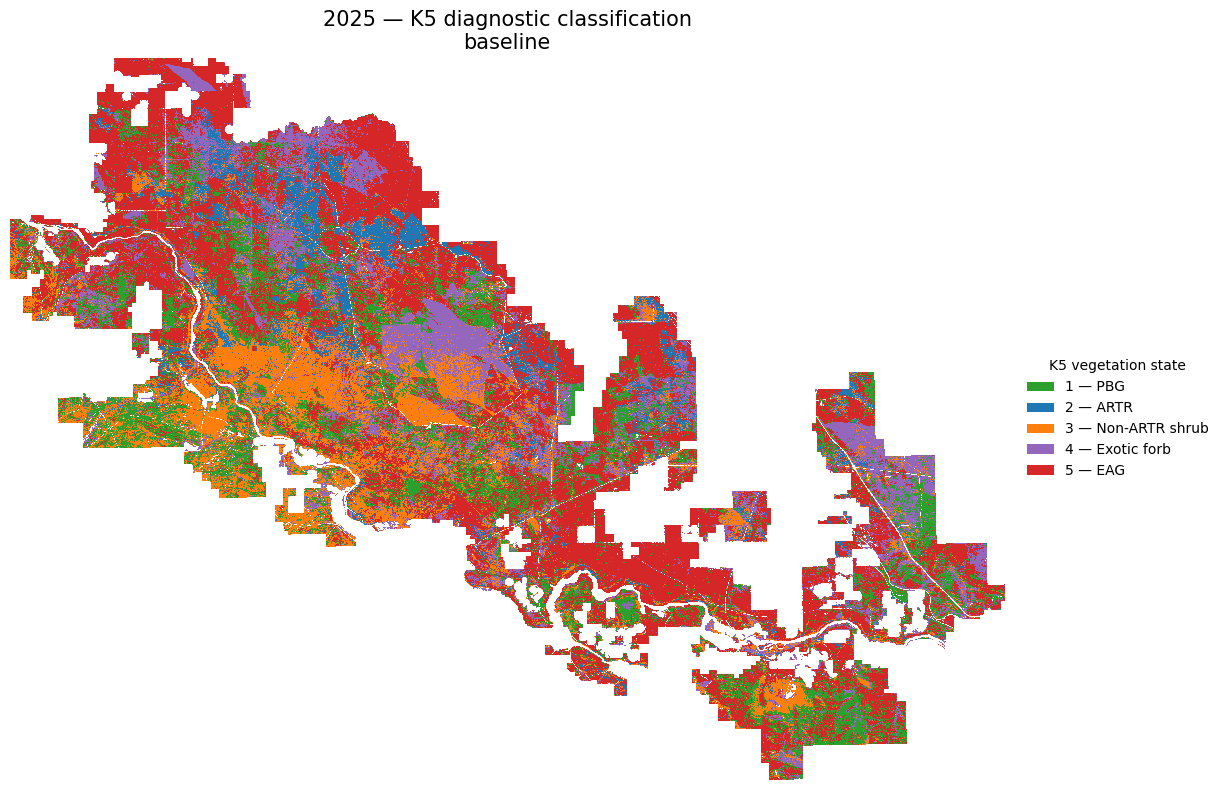

Saved: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Figures\2025_baseline_classification.png


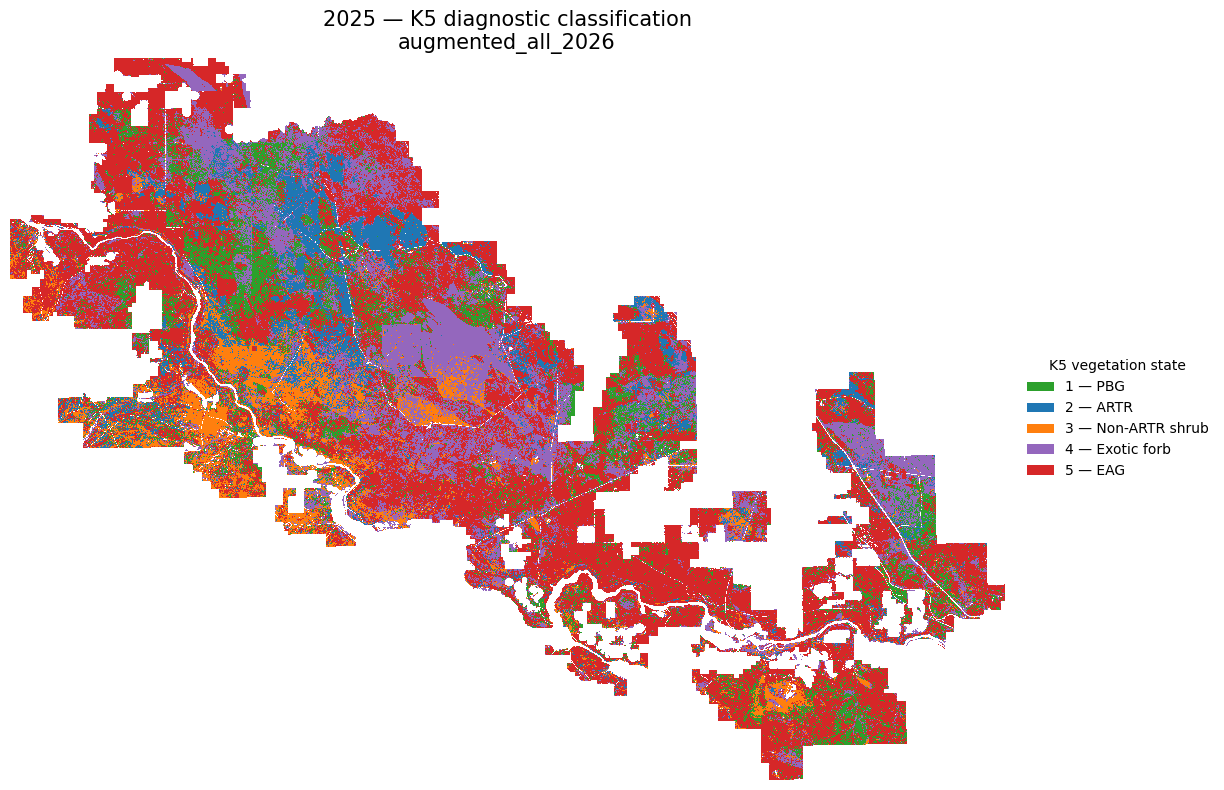

Saved: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Figures\2025_augmented_all_2026_classification.png


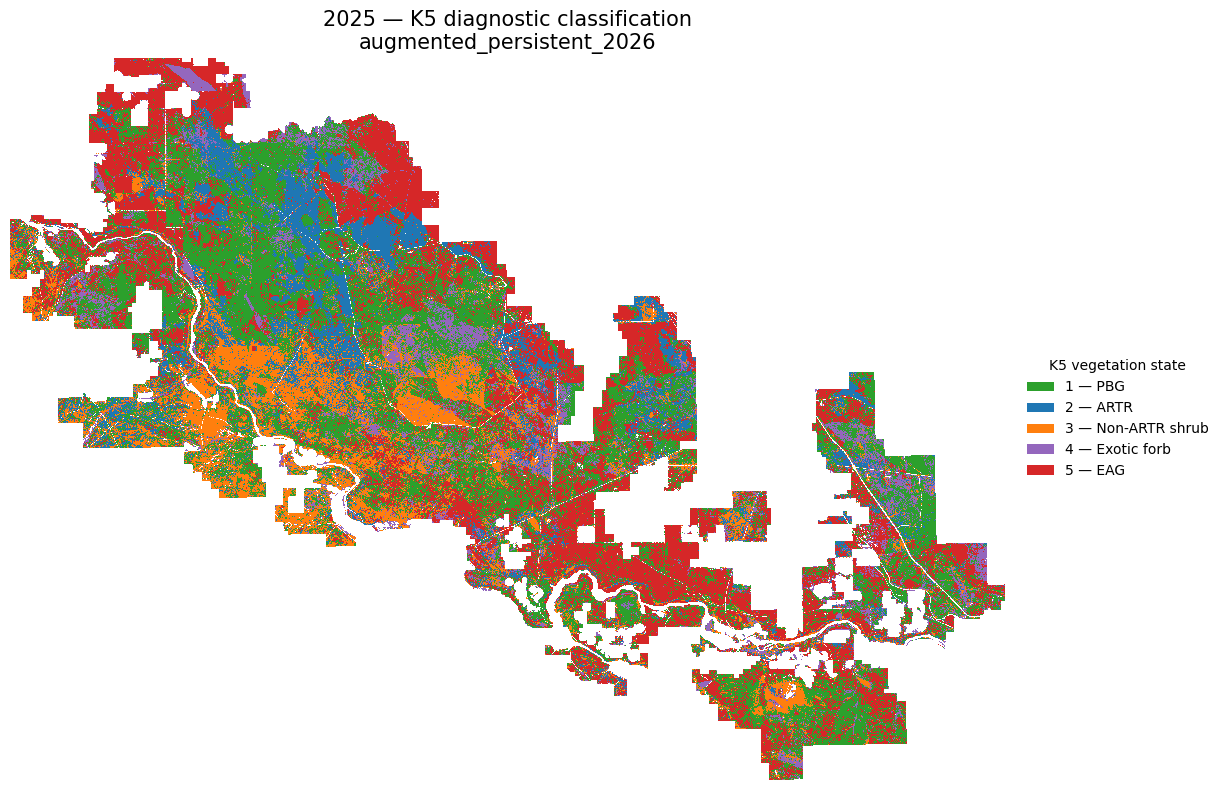

Saved: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Figures\2025_augmented_persistent_2026_classification.png


In [27]:
# =============================================================================
# 16. CLASSIFICATION MAPS
# =============================================================================

def clipped_raster(
    raster_path,
    boundary_gdf,
    band=1,
):

    with rasterio.open(
        raster_path
    ) as src:

        boundary = boundary_gdf.to_crs(
            src.crs
        )


        arr, transform = rasterio.mask.mask(
            src,
            boundary.geometry,
            crop=True,
            indexes=band,
            filled=True,
            nodata=src.nodata,
        )


        if arr.ndim == 3:

            arr = arr[
                0
            ]


        height, width = arr.shape

        west, south, east, north = array_bounds(
            height,
            width,
            transform,
        )


        extent = [
            west,
            east,
            south,
            north,
        ]


    return (
        arr,
        extent,
    )


if (
    RUN_2025_MAPPING
    and DISPLAY_MAPS
):

    nca = gpd.read_file(
        TRUE_NCA_BOUNDARY
    )


    legend_handles = [
        Patch(
            facecolor=K5_COLORS[
                code_i - 1
            ],
            label=f"{code_i} — {K5_LABELS[code_i]}",
        )
        for code_i in K5_CODES
    ]


    for scenario in [
        "baseline",
        "augmented_all_2026",
        "augmented_persistent_2026",
    ]:

        class_path = Path(
            mapping_df.loc[
                mapping_df[
                    "scenario"
                ].eq(
                    scenario
                ),
                "class_path",
            ].iloc[
                0
            ]
        )


        arr, extent = clipped_raster(
            class_path,
            nca,
            band=1,
        )


        display_arr = np.ma.masked_where(
            arr
            == 0,
            arr,
        )


        fig, ax = plt.subplots(
            figsize=(
                12,
                8,
            )
        )


        ax.imshow(
            display_arr,
            cmap=K5_CMAP,
            vmin=1,
            vmax=5,
            extent=extent,
            origin="upper",
            interpolation="nearest",
        )


        ax.set_title(
            f"2025 — K5 diagnostic classification\n{scenario}",
            fontsize=15,
        )


        ax.legend(
            handles=legend_handles,
            title="K5 vegetation state",
            loc="center left",
            bbox_to_anchor=(
                1.01,
                0.5,
            ),
            frameon=False,
        )


        ax.set_axis_off()


        plt.tight_layout()


        fig_path = (
            FIG_DIR
            / f"2025_{scenario}_classification.png"
        )


        fig.savefig(
            fig_path,
            dpi=250,
            bbox_inches="tight",
        )


        plt.show()
        plt.close(
            fig
        )


        print(
            "Saved:",
            fig_path,
        )

# 17. Plot every 2025 uncertainty map

The uncertainty visualization uses **normalized predictive entropy**:

- 0 = concentrated model votes;
- 1 = maximally diffuse votes across the five K5 classes.

Each scenario is plotted separately and saved as a PNG.

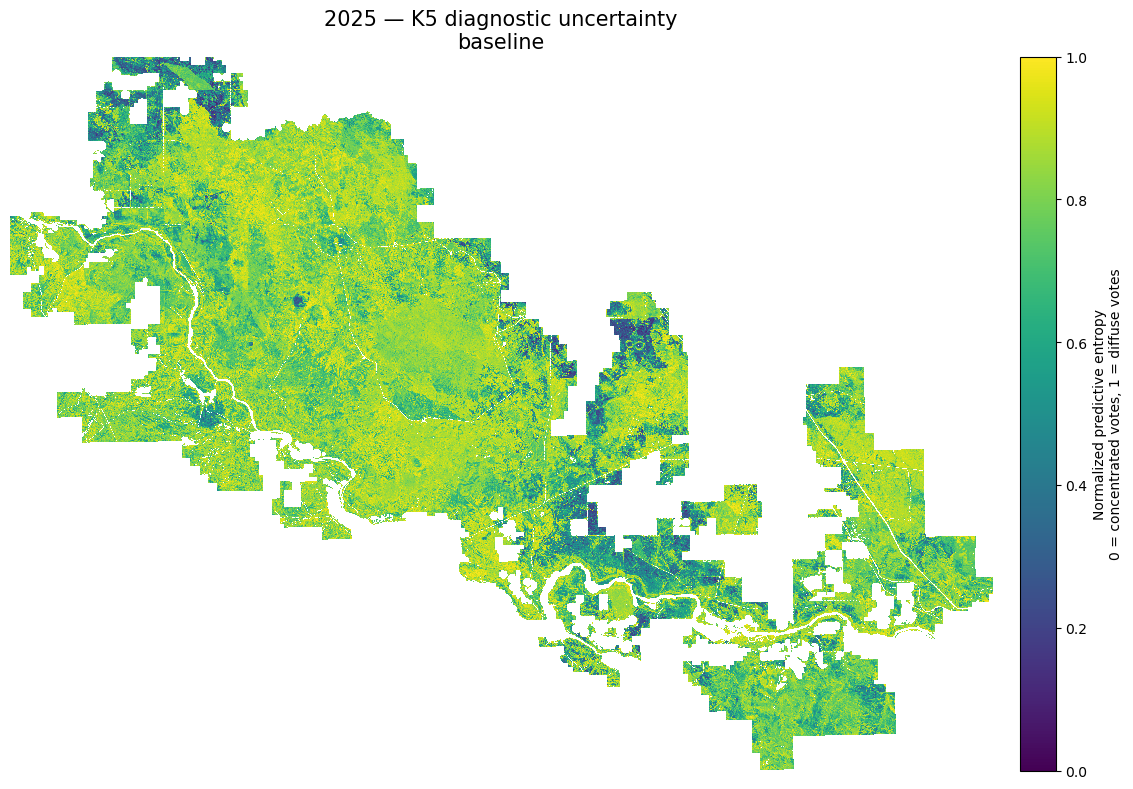

Saved: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Figures\2025_baseline_normalized_entropy.png


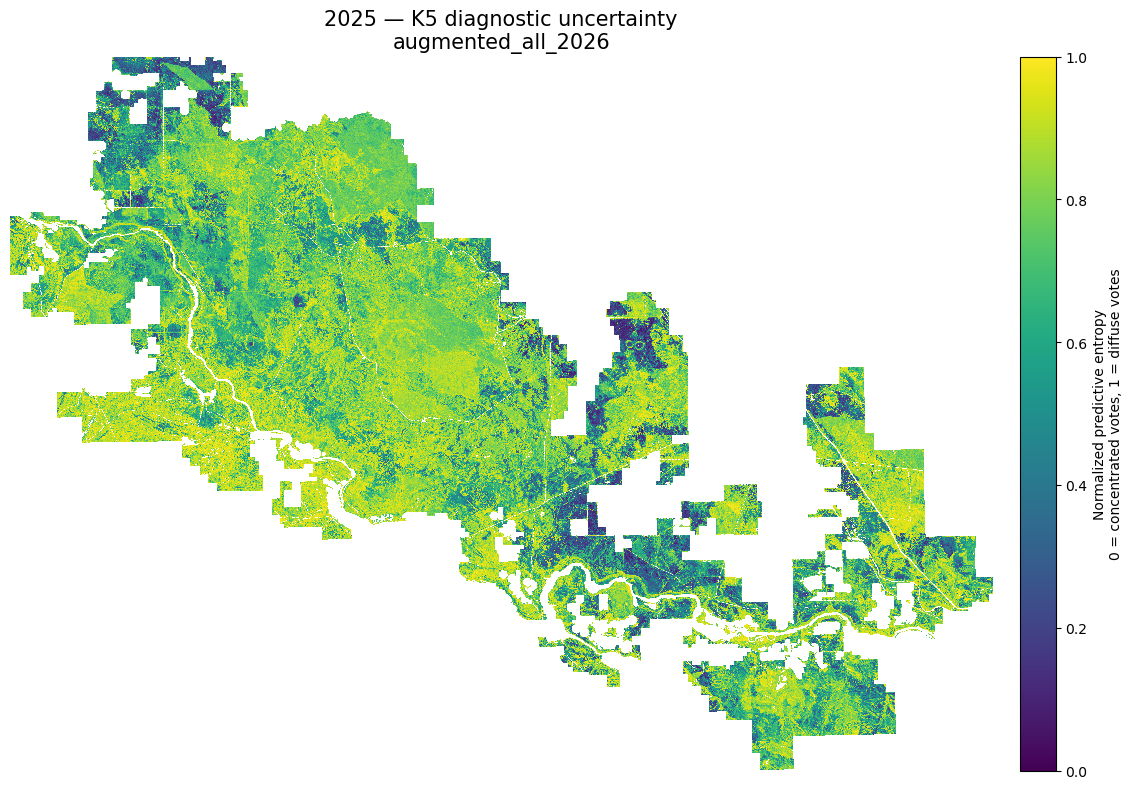

Saved: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Figures\2025_augmented_all_2026_normalized_entropy.png


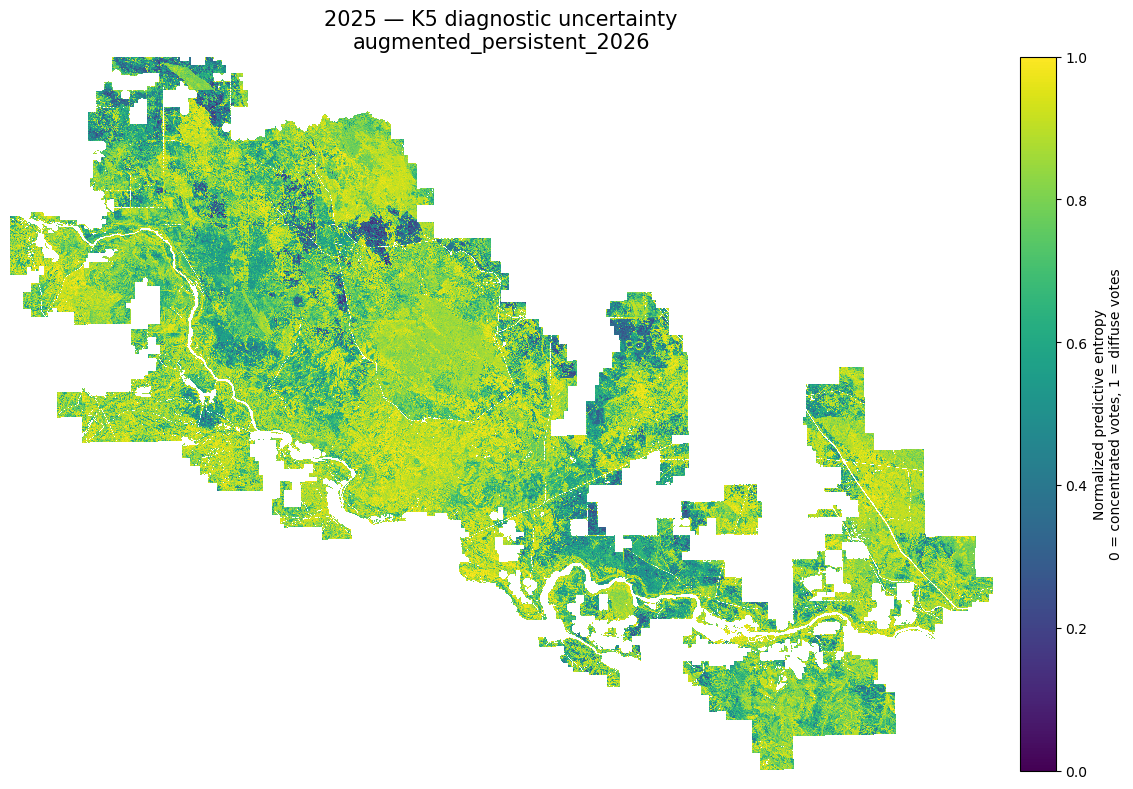

Saved: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Figures\2025_augmented_persistent_2026_normalized_entropy.png


In [28]:
# =============================================================================
# 17. NORMALIZED ENTROPY UNCERTAINTY MAPS
# =============================================================================

if (
    RUN_2025_MAPPING
    and DISPLAY_MAPS
):

    nca = gpd.read_file(
        TRUE_NCA_BOUNDARY
    )


    for scenario in [
        "baseline",
        "augmented_all_2026",
        "augmented_persistent_2026",
    ]:

        uncertainty_path = Path(
            mapping_df.loc[
                mapping_df[
                    "scenario"
                ].eq(
                    scenario
                ),
                "uncertainty_path",
            ].iloc[
                0
            ]
        )


        entropy, extent = clipped_raster(
            uncertainty_path,
            nca,
            band=3,
        )


        valid = (
            np.isfinite(
                entropy
            )
            & (
                entropy
                >= 0
            )
        )


        normalized_entropy = np.full(
            entropy.shape,
            np.nan,
            dtype=np.float32,
        )


        normalized_entropy[
            valid
        ] = (
            entropy[
                valid
            ]
            / np.log(
                len(
                    K5_CODES
                )
            )
        )


        display_entropy = np.ma.masked_invalid(
            normalized_entropy
        )


        fig, ax = plt.subplots(
            figsize=(
                12,
                8,
            )
        )


        im = ax.imshow(
            display_entropy,
            cmap="viridis",
            vmin=0,
            vmax=1,
            extent=extent,
            origin="upper",
            interpolation="nearest",
        )


        cbar = fig.colorbar(
            im,
            ax=ax,
            fraction=0.035,
            pad=0.025,
        )


        cbar.set_label(
            "Normalized predictive entropy\n0 = concentrated votes, 1 = diffuse votes",
            rotation=90,
        )


        ax.set_title(
            f"2025 — K5 diagnostic uncertainty\n{scenario}",
            fontsize=15,
        )


        ax.set_axis_off()


        plt.tight_layout()


        fig_path = (
            FIG_DIR
            / f"2025_{scenario}_normalized_entropy.png"
        )


        fig.savefig(
            fig_path,
            dpi=250,
            bbox_inches="tight",
        )


        plt.show()
        plt.close(
            fig
        )


        print(
            "Saved:",
            fig_path,
        )

## Interpretation guardrails

The primary support hypothesis is strengthened if the augmented models improve on the **same held-out baseline targets**, especially if:

- balanced accuracy and macro F1 increase;
- ARTR / shrub / PBG classwise recall improves;
- gains persist under 5-km spatial-block validation;
- wall-to-wall \(p_\max\) and margins increase;
- normalized entropy decreases.

The persistent-only sensitivity is particularly informative because it avoids borrowing 2025 optical conditions for the two most annually variable coarse classes.

Hard-class map differences among the three scenarios are **not ecological transitions**. All three maps classify the exact same 2025 optical surface. Their differences arise solely from changing the training support.

A negative result remains ambiguous because this diagnostic intentionally pairs 2026 vegetation with 2025 imagery.

The final contemporaneous test remains:

\[
V_{2026}
\leftrightarrow
Z_{2026}.
\]

In [29]:
# =============================================================================
# 18. OUTPUT MANIFEST
# =============================================================================

print(
    "=" * 100
)

print(
    "RESOLVED K5 2026→2025 SUPPORT DIAGNOSTIC COMPLETE"
)

print(
    "=" * 100
)

print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)


for label, directory in [
    (
        "Tables",
        TABLE_DIR,
    ),
    (
        "Maps",
        MAP_DIR,
    ),
    (
        "Figures",
        FIG_DIR,
    ),
]:

    print(
        f"\n{label}:"
    )

    for path in sorted(
        directory.glob(
            "*"
        )
    ):

        print(
            " ",
            path.name
        )

RESOLVED K5 2026→2025 SUPPORT DIAGNOSTIC COMPLETE

Output directory:
C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1

Tables:
  DIAGNOSTIC_2025_class_map_agreement.csv
  DIAGNOSTIC_2025_mapping_runtime.csv
  DIAGNOSTIC_2025_uncertainty_by_class.csv
  DIAGNOSTIC_2025_uncertainty_delta_vs_baseline.csv
  DIAGNOSTIC_2025_uncertainty_global.csv
  DIAGNOSTIC_2026_nearest_baseline.csv
  DIAGNOSTIC_2026_spatial_support_summary.csv
  DIAGNOSTIC_2026_to_2025_sampling_audit.csv
  DIAGNOSTIC_2026_vegetation_coordinate_crosswalk.csv
  DIAGNOSTIC_2026veg_sampled_at_2025_IA45_z.csv
  DIAGNOSTIC_groupedOOF_classwise_delta_vs_baseline.csv
  DIAGNOSTIC_groupedOOF_classwise_metrics.csv
  DIAGNOSTIC_groupedOOF_delta_vs_baseline.csv
  DIAGNOSTIC_groupedOOF_fold_metrics.csv
  DIAGNOSTIC_groupedOOF_pooled_metrics.csv
  DIAGNOSTIC_spatialCV_fold_metrics.csv
  DIAGNOSTIC_spatialCV_pooled_metrics.csv
  DIAGNOSTIC_support_counts.csv
  DIAGNOSTIC_unmatched_2026_spatial_ids.csv

Maps:
  DIAGNO

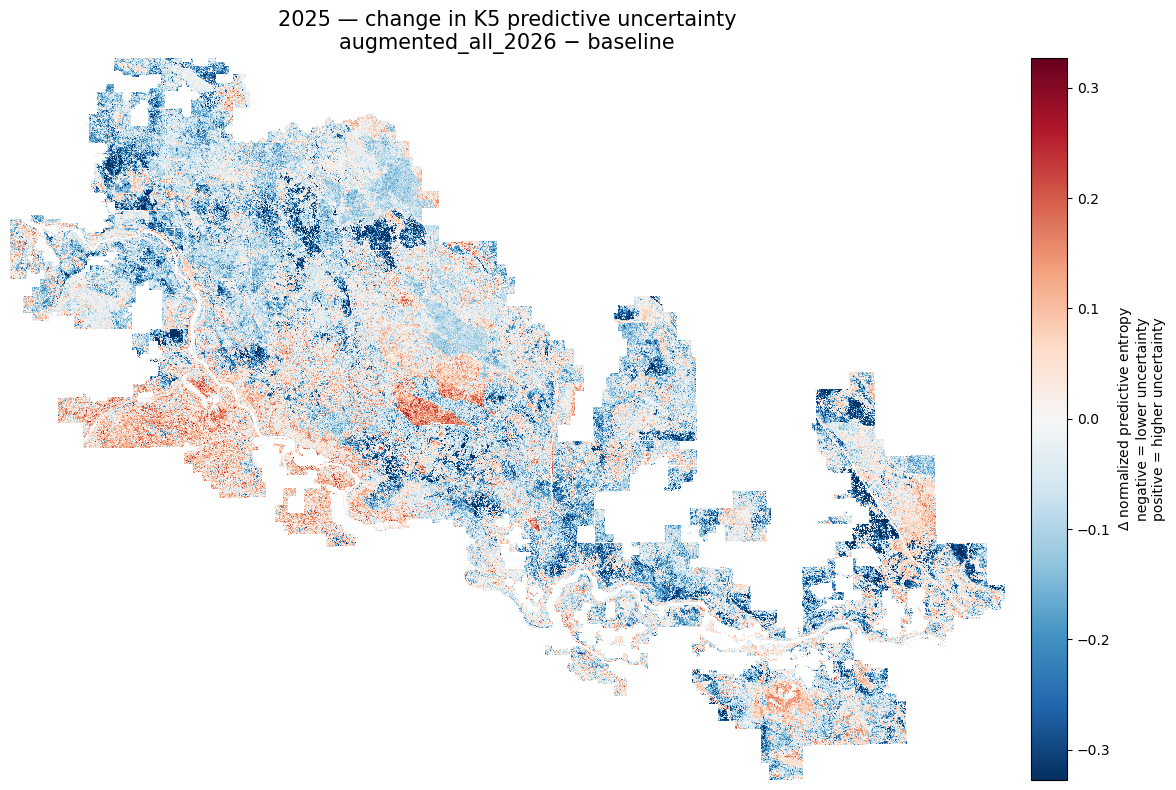

Saved: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Figures\2025_augmented_all_2026_delta_normalized_entropy_vs_baseline.png


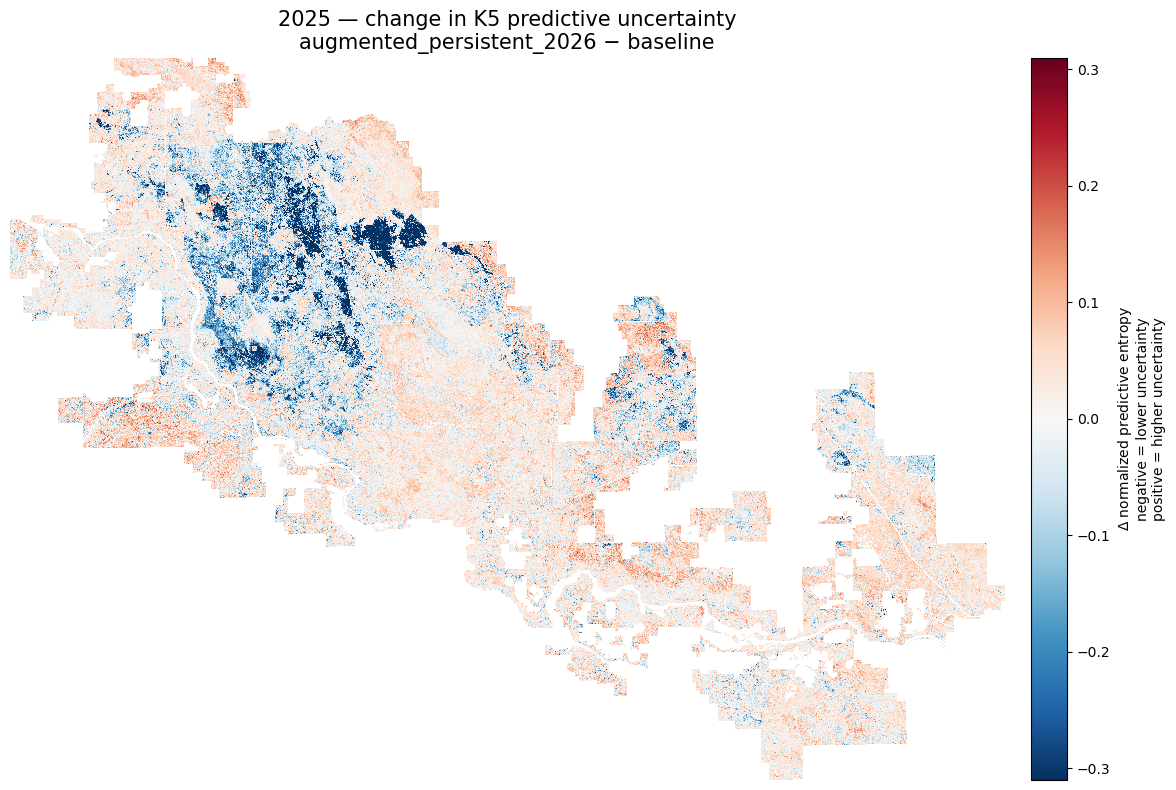

Saved: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Figures\2025_augmented_persistent_2026_delta_normalized_entropy_vs_baseline.png
Wrote: C:\NCA_DATA\Analysis\Diagnostics\K5_2026Veg_as2025Optics_RESOLVED_v1\Tables\DIAGNOSTIC_2025_entropy_change_vs_baseline.csv

Entropy-change summary:


,scenario,n_pixels,mean_delta_Hnorm,median_delta_Hnorm,p10_delta_Hnorm,p90_delta_Hnorm,fraction_uncertainty_decreased,fraction_uncertainty_increased,fraction_abs_change_lt_0p01
0,augmented_all_2026,22062129,-0.0491,-0.0388,-0.1977,0.0845,0.6578,0.3422,0.0774
1,augmented_persistent_2026,22062129,-0.0074,0.0140,-0.1137,0.0746,0.3973,0.6027,0.1315


In [30]:
# =============================================================================
# 18. MAP CHANGE IN NORMALIZED ENTROPY RELATIVE TO BASELINE
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


if RUN_2025_MAPPING and DISPLAY_MAPS:

    nca = gpd.read_file(
        TRUE_NCA_BOUNDARY
    )


    # -------------------------------------------------------------------------
    # BASELINE ENTROPY
    # -------------------------------------------------------------------------

    baseline_uncertainty_path = Path(
        mapping_df.loc[
            mapping_df[
                "scenario"
            ].eq(
                "baseline"
            ),
            "uncertainty_path",
        ].iloc[
            0
        ]
    )


    baseline_entropy, baseline_extent = clipped_raster(
        baseline_uncertainty_path,
        nca,
        band=3,
    )


    baseline_valid = (
        np.isfinite(
            baseline_entropy
        )
        & (
            baseline_entropy
            >= 0
        )
    )


    baseline_Hnorm = np.full(
        baseline_entropy.shape,
        np.nan,
        dtype=np.float32,
    )


    baseline_Hnorm[
        baseline_valid
    ] = (
        baseline_entropy[
            baseline_valid
        ]
        / np.log(
            len(
                K5_CODES
            )
        )
    )


    # -------------------------------------------------------------------------
    # COMPARE AUGMENTED MODELS TO BASELINE
    # -------------------------------------------------------------------------

    entropy_change_rows = []


    for scenario in [
        "augmented_all_2026",
        "augmented_persistent_2026",
    ]:

        uncertainty_path = Path(
            mapping_df.loc[
                mapping_df[
                    "scenario"
                ].eq(
                    scenario
                ),
                "uncertainty_path",
            ].iloc[
                0
            ]
        )


        entropy, extent = clipped_raster(
            uncertainty_path,
            nca,
            band=3,
        )


        if entropy.shape != baseline_entropy.shape:

            raise ValueError(
                f"{scenario}: entropy raster shape differs from baseline."
            )


        valid = (
            np.isfinite(
                entropy
            )
            & (
                entropy
                >= 0
            )
            & np.isfinite(
                baseline_Hnorm
            )
        )


        Hnorm = np.full(
            entropy.shape,
            np.nan,
            dtype=np.float32,
        )


        Hnorm[
            valid
        ] = (
            entropy[
                valid
            ]
            / np.log(
                len(
                    K5_CODES
                )
            )
        )


        delta_H = np.full(
            entropy.shape,
            np.nan,
            dtype=np.float32,
        )


        delta_H[
            valid
        ] = (
            Hnorm[
                valid
            ]
            - baseline_Hnorm[
                valid
            ]
        )


        # ---------------------------------------------------------------------
        # SUMMARY STATISTICS
        # ---------------------------------------------------------------------

        d = delta_H[
            np.isfinite(
                delta_H
            )
        ]


        entropy_change_rows.append(
            {
                "scenario": scenario,
                "n_pixels": len(
                    d
                ),
                "mean_delta_Hnorm": float(
                    np.mean(
                        d
                    )
                ),
                "median_delta_Hnorm": float(
                    np.median(
                        d
                    )
                ),
                "p10_delta_Hnorm": float(
                    np.quantile(
                        d,
                        0.10,
                    )
                ),
                "p90_delta_Hnorm": float(
                    np.quantile(
                        d,
                        0.90,
                    )
                ),
                "fraction_uncertainty_decreased": float(
                    np.mean(
                        d
                        < 0
                    )
                ),
                "fraction_uncertainty_increased": float(
                    np.mean(
                        d
                        > 0
                    )
                ),
                "fraction_abs_change_lt_0p01": float(
                    np.mean(
                        np.abs(
                            d
                        )
                        < 0.01
                    )
                ),
            }
        )


        # ---------------------------------------------------------------------
        # ROBUST SYMMETRIC DISPLAY LIMIT
        #
        # Use the 98th percentile of absolute change so isolated extreme pixels
        # do not dominate the diverging color scale.
        # ---------------------------------------------------------------------

        vmax = float(
            np.quantile(
                np.abs(
                    d
                ),
                0.98,
            )
        )


        if (
            not np.isfinite(
                vmax
            )
            or vmax == 0
        ):

            vmax = 0.10


        # ---------------------------------------------------------------------
        # PLOT
        # ---------------------------------------------------------------------

        display_delta = np.ma.masked_invalid(
            delta_H
        )


        fig, ax = plt.subplots(
            figsize=(
                12,
                8,
            )
        )


        im = ax.imshow(
            display_delta,
            cmap="RdBu_r",
            vmin=-vmax,
            vmax=vmax,
            extent=extent,
            origin="upper",
            interpolation="nearest",
        )


        cbar = fig.colorbar(
            im,
            ax=ax,
            fraction=0.035,
            pad=0.025,
        )


        cbar.set_label(
            r"$\Delta$ normalized predictive entropy"
            "\nnegative = lower uncertainty"
            "\npositive = higher uncertainty",
            rotation=90,
        )


        ax.set_title(
            "2025 — change in K5 predictive uncertainty\n"
            f"{scenario} − baseline",
            fontsize=15,
        )


        ax.set_axis_off()


        plt.tight_layout()


        fig_path = (
            FIG_DIR
            / f"2025_{scenario}_delta_normalized_entropy_vs_baseline.png"
        )


        fig.savefig(
            fig_path,
            dpi=250,
            bbox_inches="tight",
        )


        plt.show()
        plt.close(
            fig
        )


        print(
            "Saved:",
            fig_path,
        )


    # -------------------------------------------------------------------------
    # SUMMARY TABLE
    # -------------------------------------------------------------------------

    entropy_change_df = pd.DataFrame(
        entropy_change_rows
    )


    write_csv_safe(
        entropy_change_df,
        TABLE_DIR
        / "DIAGNOSTIC_2025_entropy_change_vs_baseline.csv",
    )


    print(
        "\nEntropy-change summary:"
    )


    display(
        entropy_change_df.round(
            4
        )
    )